---
title: "Volatility Forecasts (Part 5 - Feature Addition and Selection)"
date: 2026-03-03
description: "We hold the Part 4 baseline setup fixed, add HAR, calendar, event, and positioning features to STES and XGBSTES, and use regularization to see which predictors the gate actually needs."
categories: [Quantitative Finance, Volatility Modeling, Time Series]
content-type: "series"
series-id: "volatility-forecasting"
series-title: "Volatility Forecasts"
series-part: 5
project-ids: [volatility-forecasting]
format:
  html:
    toc: true
    code-fold: true
execute:
  echo: true
  warning: false
  message: false
  freeze: false
---

## Introduction

In [Part 4](../volatility-forecasts-4/) of this series, we held the core SPY forecasting design fixed and asked how the main benchmark models compare under RMSE and QLIKE. This post keeps that same sample and split, but changes the question from `which loss should we optimize?` to `which added predictors actually help the gate?`

In a separate signature-methods series, [Part 4](../signature-method-4/) tested signature features in STES and XGBSTES and found limited incremental value. Here I return to feature expansion from a more classical volatility-modeling angle, focusing on Heterogeneous Autoregressive (HAR) components, simple calendar-based covariates and public position flow data.

I also broaden the set of benchmark models. Realized-volatility forecasting has traditionally leaned on linear autoregressive structures: HAR captures short-, medium-, and long-horizon persistence, while the ARCH/GARCH family captures volatility clustering. GARCH, in particular, is similar to an Exponential Smoothing (ES) of past squared returns (as discussed in [Part 1](../volatility-forecasts-1/)). The dynamic smoothing models in this series offer a nonlinear alternative by allowing the smoothing parameter to vary with the observed state.

That leads to four practical questions:

1. **How do the dynamic smoothing models compare with classical baselines?** We evaluate STES and XGBSTES against HAR-RV and GARCH(1,1) under a more rigorous statistical out-of-sample design than we did in previous parts.
2. **What do HAR, calendar, and event features actually add?** We isolate the marginal predictive contribution of HAR-style features, calendar indicators (day-of-week and business period-end structure), scheduled event dates (FOMC, options expiration, IMM), and weekly leveraged fund flow, when they enter the gating equations.
3. **Which features does the model actually *need*?** Adding features is only half the story. We introduce sparsity-inducing regularization - adaptive LASSO for STES and L1 penalization for XGBSTES - to let the model itself decide which covariates carry genuine signal and which are noise. The distinction matters: a feature the model *uses* (because it was given) is not the same as a feature it *needs* (one it would select if forced to justify the complexity cost). Ridge regularization, introduced in [Part 4 of the Signature Methods series](../signature-method-4/), shrinks coefficients toward zero but never sets them exactly to zero; sparsity penalties close that gap.
4. **Which added features matter most once they are included?** Rather than building a long behavioral story around the gate, I close with a coefficient readout that shows which variables receive the largest loadings in the richest specification after sparsity selection.

We use the same SPY sample spanning January 2000 through December 2023. To stay comparable with [Part 4](../volatility-forecasts-4/), we discard the first 200 observations as a warm-up period, use observations 201 through 4,000 for training, and reserve the remainder for out-of-sample evaluation. The target variable is next-day squared return.

In [1]:
#| echo: false
#| output: false


import sys
import os
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# --- PATH SETUP ---
WORKSPACE_ROOT = Path("/Users/steveyang/Projects/Github")
BLOG_PATH = WORKSPACE_ROOT / "steveya.github.io"
VF_PATH = WORKSPACE_ROOT / "volatility-forecast"
AF_PATH = WORKSPACE_ROOT / "alphaforge"

for p in (BLOG_PATH, VF_PATH, AF_PATH):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

load_dotenv(VF_PATH / ".env")
logging.basicConfig(level=logging.ERROR)

# --- LIBRARY IMPORTS ---
from alphaforge.data.cache import FileCacheBackend
from alphaforge.data.query import Query
from volatility_forecast.pipeline import build_default_ctx
from volatility_forecast.sources import TiingoEODSource
from volatility_forecast.evaluation.metrics import rmse, mae, qlike
from volatility_forecast.evaluation.dm_test import diebold_mariano
from volatility_forecast.evaluation.mz import mincer_zarnowitz

from blog_styles import (
    style_results_table, inject_blog_table_css,
    apply_blog_plot_style, BLOG_PALETTE,
)

# Replication cache lock (same cache path convention as script)
SCRIPT_CACHE_DIR = VF_PATH / ".af_cache"
SCRIPT_CACHE_MODE = "use"

# --- STYLES ---
inject_blog_table_css()
apply_blog_plot_style()

# --- DATA CONTEXT ---
cache = FileCacheBackend(SCRIPT_CACHE_DIR)
ctx = build_default_ctx(
    tiingo_api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode=SCRIPT_CACHE_MODE,
)
print(f"Tiingo cache dir: {SCRIPT_CACHE_DIR}")
print(f"Tiingo cache mode: {SCRIPT_CACHE_MODE}")

Tiingo cache dir: /Users/steveyang/Projects/Github/volatility-forecast/.af_cache
Tiingo cache mode: use


In [2]:
#| echo: false
#| output: false

# Shared sample window used throughout the notebook
SAMPLE_TICKER = "SPY"
SAMPLE_START = pd.Timestamp("2000-01-01", tz="UTC")
SAMPLE_END = pd.Timestamp("2023-12-31", tz="UTC")

# TiingoEODSource cache key convention: "{ticker}|adj={use_adjusted}"
sample_cache_key = f"{SAMPLE_TICKER}|adj=True"
sample_cached = cache.get(sample_cache_key)

if sample_cached is None or sample_cached.empty:
    raise RuntimeError(
        f"Cache-only mode: no cached data found for key={sample_cache_key} in {SCRIPT_CACHE_DIR}. "
        "Populate cache via script first; notebook will not reload from Tiingo."
    )

sample_cached = sample_cached.copy()
sample_cached["date"] = pd.to_datetime(sample_cached["date"], utc=True).dt.normalize()
cache_min = sample_cached["date"].min()
cache_max = sample_cached["date"].max()

# Compare against business-day endpoints (requested endpoints may be weekends/holidays)
requested_bdays = pd.bdate_range(SAMPLE_START.tz_convert(None), SAMPLE_END.tz_convert(None))
need_start = pd.Timestamp(requested_bdays.min(), tz="UTC")
need_end = pd.Timestamp(requested_bdays.max(), tz="UTC")

if not (cache_min <= need_start and cache_max >= need_end):
    raise RuntimeError(
        "Cache-only mode: cached coverage is insufficient for sample window. "
        f"Need business-day coverage [{need_start.date()}..{need_end.date()}], "
        f"have [{cache_min.date()}..{cache_max.date()}]. "
        "Populate cache via script first; notebook will not reload from Tiingo."
    )

print(f"Cache preflight OK for {SAMPLE_TICKER}")
print(f"Required business-day range: {need_start.date()} → {need_end.date()}")
print(f"Coverage in cache: {cache_min.date()} → {cache_max.date()}")

Cache preflight OK for SPY
Required business-day range: 2000-01-03 → 2023-12-29
Coverage in cache: 2000-01-03 → 2023-12-29


## Methodology: Baseline and Augmented Models

We compare five baseline architectures before adding features. Let $y_t = r_t^2$ denote realized variance at time $t$ and let $\hat{y}_{t+1|t}$ denote the one-step-ahead forecast.

- **HAR-RV**: OLS regression on daily ($RV_t$), weekly ($\overline{RV}^{(5)}_t$), and monthly ($\overline{RV}^{(22)}_t$) rolling realized variance averages. This is the standard linear benchmark from [Corsi (2009)](https://doi.org/10.1093/jjfinec/nbp001).
  $$
  \hat{y}_{t+1|t} = \beta_0 + \beta_d RV_t + \beta_w \overline{RV}^{(5)}_t + \beta_m \overline{RV}^{(22)}_t,
  $$
  with
  $$
  \overline{RV}^{(5)}_t = \frac{1}{5}\sum_{i=0}^{4} RV_{t-i},
  \qquad
  \overline{RV}^{(22)}_t = \frac{1}{22}\sum_{i=0}^{21} RV_{t-i}.
  $$

- **GARCH(1,1)**: The workhorse of conditional variance modeling. We fit it using maximum likelihood and extract one-step-ahead variance forecasts.
  $$
  \sigma_{t+1}^2 = \omega + \alpha r_t^2 + \beta \sigma_t^2,
  $$
  and use $\hat{y}_{t+1|t} = \sigma_{t+1}^2$.

- **ES**: Exponential Smoothing with a static smoothing parameter $\alpha$, optimized over the training set.
  $$
  \hat{y}_{t+1|t} = \alpha y_t + (1-\alpha)\hat{y}_{t|t-1}.
  $$

- **STES**: Smooth-Transition ES where $\alpha_t = \sigma(\mathbf{x}_t^\top \boldsymbol{\beta})$ adapts to the current state via a logistic gate.
  $$
  \alpha_t = \frac{1}{1+e^{-\mathbf{x}_t^\top\boldsymbol{\beta}}},
  \qquad
  \hat{y}_{t+1|t} = \alpha_t y_t + (1-\alpha_t)\hat{y}_{t|t-1}.
  $$

- **XGBSTES**: Our end-to-end variant that replaces the linear gate with a gradient-boosted linear model (coordinate-descent booster).
  $$
  \alpha_t = \frac{1}{1+e^{-f_{\text{XGB}}(\mathbf{x}_t)}},
  \qquad
  \hat{y}_{t+1|t} = \alpha_t y_t + (1-\alpha_t)\hat{y}_{t|t-1}.
  $$

We report three metrics: RMSE (standard error magnitude), MAE (robust to outliers), and QLIKE (the natural loss function for variance forecasts, which penalizes under-prediction more heavily).

In [3]:
#| code-fold: true
#| code-summary: "Get previous STES/XGBSTES dataset (cache-only)"

from volatility_forecast.pipeline import build_vol_dataset, VolDatasetSpec
from alphaforge.features.dataset_spec import (
    UniverseSpec, TimeSpec, FeatureRequest, TargetRequest, JoinPolicy, MissingnessPolicy,
)
from volatility_forecast.features.return_features import (
    LagLogReturnTemplate, LagAbsLogReturnTemplate, LagSquaredLogReturnTemplate,
)
from volatility_forecast.targets.squared_return import NextDaySquaredReturnTarget


def build_dataset_spec_sample(source: str, ticker: str, start, end, lags: int) -> VolDatasetSpec:
    features = (
        FeatureRequest(
            template=LagLogReturnTemplate(),
            params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
        ),
        FeatureRequest(
            template=LagAbsLogReturnTemplate(),
            params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
        ),
        FeatureRequest(
            template=LagSquaredLogReturnTemplate(),
            params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
        ),
    )

    target = TargetRequest(
        template=NextDaySquaredReturnTarget(),
        params={"source": source, "table": "market.ohlcv", "price_col": "close", "scale": 1.0},
        horizon=1,
        name="y",
    )

    return VolDatasetSpec(
        universe=UniverseSpec(entities=[ticker]),
        time=TimeSpec(start=start, end=end, calendar="XNYS", grid="B", asof=None),
        features=features,
        target=target,
        join_policy=JoinPolicy(how="inner", sort_index=True),
        missingness=MissingnessPolicy(final_row_policy="drop_if_any_nan"),
    )


spec_sample = build_dataset_spec_sample(
    source="tiingo",
    ticker=SAMPLE_TICKER,
    start=SAMPLE_START,
    end=SAMPLE_END,
    lags=0,
)

# Cache-only context (same cache path/mode as script convention)
ctx_sample = build_default_ctx(
    tiingo_api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode="use",
)

X_raw, y_raw, r_raw, _ = build_vol_dataset(ctx_sample, spec_sample, persist=False)

if isinstance(X_raw.index, pd.MultiIndex):
    X_par = X_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
    y_par = y_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
    r_par = r_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
else:
    X_par = X_raw.sort_index().astype(float)
    y_par = y_raw.sort_index().astype(float)
    r_par = r_raw.sort_index().astype(float)

if "const" not in X_par.columns:
    X_par["const"] = 1.0

# Align all objects
common_idx = X_par.index.intersection(y_par.index).intersection(r_par.index)
X_par = X_par.loc[common_idx]
y_par = y_par.loc[common_idx]
r_par = r_par.loc[common_idx]

print(f"Sample dataset rows: {len(X_par)}")
print(f"Sample date range: {X_par.index.min().date()} → {X_par.index.max().date()}")
print(f"Feature columns: {list(X_par.columns)}")

Sample dataset rows: 6035
Sample date range: 2000-01-04 → 2023-12-28
Feature columns: ['lag.logret.fc5d3612d9c7', 'lag.abslogret.1ad490bcb584', 'lag.sqlogret.c2cf3aa70c10', 'const']


In [4]:
#| code-fold: true
#| code-summary: "Fixed split, HAR-RV, and GARCH(1,1) setup"

import statsmodels.api as sm
from arch import arch_model

# Match the historical Part 3 protocol exactly for the shared baseline block.
SAMPLE_TRAIN_START = 200
SAMPLE_SPLIT_INDEX = 4000

if len(X_par) <= SAMPLE_SPLIT_INDEX:
    raise RuntimeError(
        f"Need more than {SAMPLE_SPLIT_INDEX} rows for fixed split, got {len(X_par)}"
    )

X_tr = X_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
X_te = X_par.iloc[SAMPLE_SPLIT_INDEX:]
y_tr = y_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
y_te = y_par.iloc[SAMPLE_SPLIT_INDEX:]
r_tr = r_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
r_te = r_par.iloc[SAMPLE_SPLIT_INDEX:]

print(f"Train rows: {len(X_tr)} ({X_tr.index.min().date()} → {X_tr.index.max().date()})")
print(f"Test rows:  {len(X_te)} ({X_te.index.min().date()} → {X_te.index.max().date()})")

# ── HAR-RV ──────────────────────────────────────────────────────────────
rv_par = r_par ** 2
har_par_df = pd.DataFrame(
    {
        "rv": rv_par,
        "rv5": rv_par.rolling(5, min_periods=1).mean(),
        "rv22": rv_par.rolling(22, min_periods=1).mean(),
        "y_target": y_par,
    },
    index=rv_par.index,
)

Xh_tr = sm.add_constant(har_par_df.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX][["rv", "rv5", "rv22"]])
Xh_te = sm.add_constant(har_par_df.iloc[SAMPLE_SPLIT_INDEX:][["rv", "rv5", "rv22"]])
yh_tr = har_par_df.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]["y_target"]
yh_te = har_par_df.iloc[SAMPLE_SPLIT_INDEX:]["y_target"]

har_model = sm.OLS(yh_tr, Xh_tr).fit(cov_type="HC3")
har_pred_is = har_model.predict(Xh_tr).values
har_pred_os = har_model.predict(Xh_te).values

# ── GARCH(1,1) ──────────────────────────────────────────────────────────
# Fit on training returns (percentage scale for numerical stability)
r_tr_pct = r_tr * 100.0
r_all_concat = pd.concat([r_tr, r_te])
r_all_pct = r_all_concat * 100.0
garch_train_len = len(r_tr)

garch_spec = arch_model(r_tr_pct, vol="GARCH", p=1, q=1, mean="Zero", rescale=False)
garch_fit = garch_spec.fit(disp="off")

omega_g = garch_fit.params["omega"]
alpha_g = garch_fit.params["alpha[1]"]
beta_g = garch_fit.params["beta[1]"]
print(f"\nGARCH(1,1) parameters: ω={omega_g:.6f}, α={alpha_g:.4f}, β={beta_g:.4f}")

# IS one-step-ahead: σ²_{t+1} = ω + α·r²_t + β·σ²_t predicts y[t] = r²_{t+1}
cv_sq_is = garch_fit.conditional_volatility.values ** 2  # σ²_t in pct²
r_sq_is = r_tr_pct.values ** 2                           # r²_t in pct²
garch_pred_is = (omega_g + alpha_g * r_sq_is + beta_g * cv_sq_is) / (100.0 ** 2)

# OS: fit on full data using only IS-estimated parameters, then forecast
garch_spec_full = arch_model(r_all_pct, vol="GARCH", p=1, q=1, mean="Zero", rescale=False)
garch_fit_full = garch_spec_full.fit(disp="off", last_obs=garch_train_len)

garch_fcast = garch_fit_full.forecast(start=garch_train_len, reindex=False)
garch_pred_os = garch_fcast.variance.values.flatten() / (100.0 ** 2)

print(f"GARCH IS predictions: {len(garch_pred_is)}, OS predictions: {len(garch_pred_os)}")

Train rows: 3800 (2000-10-18 → 2015-11-25)
Test rows:  2035 (2015-11-27 → 2023-12-28)

GARCH(1,1) parameters: ω=0.018841, α=0.0952, β=0.8899
GARCH IS predictions: 3800, OS predictions: 2035


In [5]:
#| label: fit-stes-xgb
#| code-fold: true
#| code-summary: "Load archived Part 3 baselines and fit HAR-augmented STES/XGBSTES"

from sklearn.preprocessing import StandardScaler
from volatility_forecast.model.stes_model import STESModel
from volatility_forecast.model.tree_stes_model import XGBoostSTESModel


def scale_data_sample(X_train, X_test):
    scaler = StandardScaler()
    cols_to_scale = [c for c in X_train.columns if c != "const"]

    if not cols_to_scale:
        return X_train.copy(), X_test.copy()

    X_tr_s = X_train.copy()
    X_te_s = X_test.copy()
    X_tr_s[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
    X_te_s[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
    return X_tr_s, X_te_s


def _align_archive_series(series, target_index):
    aligned = series.reindex(target_index)
    if aligned.isna().any():
        src = series.copy()
        src.index = pd.DatetimeIndex(src.index).tz_convert("UTC").normalize()
        tgt = pd.DatetimeIndex(target_index).tz_convert("UTC").normalize()
        aligned = src.reindex(tgt)
        aligned.index = target_index
    if aligned.isna().any():
        missing = int(aligned.isna().sum())
        raise RuntimeError(f"Archive alignment failed: {missing} missing values remain.")
    return aligned.astype(float)


SCALE_FACTOR = 100.0
XGB_PARAMS_SAMPLE = {
    "booster": "gblinear",
    "updater": "coord_descent",
    "max_depth": 5,
    "learning_rate": 0.01,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "min_child_weight": 1.0,
    "reg_lambda": 1.0,
    "reg_alpha": 0.0,
    "verbosity": 0,
}
XGB_ROUNDS_SAMPLE = 200
GRID_E2E = [
    {"min_child_weight": 5.0, "learning_rate": 0.05, "max_depth": 3},
    {"min_child_weight": 20.0, "learning_rate": 0.1, "max_depth": 3},
    {"min_child_weight": 50.0, "learning_rate": 0.05, "max_depth": 2},
]

# L2 grid for STES CV
STES_L2_GRID = [
    {"l2_reg": 0.0},
    {"l2_reg": 0.001},
    {"l2_reg": 0.01},
    {"l2_reg": 0.1},
    {"l2_reg": 1.0},
]

# Expanded grid for XGBSTES + HAR CV (adds reg_lambda search)
GRID_E2E_HAR = [
    {"min_child_weight": mcw, "learning_rate": lr, "max_depth": md, "reg_lambda": lam}
    for mcw, lr, md in [(5.0, 0.05, 3), (20.0, 0.1, 3), (50.0, 0.05, 2)]
    for lam in [0.1, 1.0, 5.0, 10.0]
]

# ---------- Shared baseline feature set ----------
X_tr_s, X_te_s = scale_data_sample(X_tr, X_te)
X_all_s = pd.concat([X_tr_s, X_te_s])
r_all = pd.concat([r_tr, r_te])

archive_dir = VF_PATH / "outputs" / "volatility_forecast_2_monte_carlo"
archive_pred_path = archive_dir / "SPY_Analysis_predictions_all_runs.csv"
if not archive_pred_path.exists():
    raise FileNotFoundError(
        f"Archived Part 3 predictions not found at {archive_pred_path}. "
        "Re-run volatility_forecast_2.py to regenerate them."
    )

archive_preds = pd.read_csv(archive_pred_path, parse_dates=["ts_utc"]).set_index("ts_utc")
archive_preds.index = pd.DatetimeIndex(archive_preds.index).tz_convert("UTC")

es_pred_all = _align_archive_series(archive_preds["ES_run_42"], X_all_s.index)
stes_pred_all = _align_archive_series(archive_preds["STES_run_42"], X_all_s.index)
xgb_pred_all = _align_archive_series(archive_preds["XGBSTES_E2E_run_42"], X_all_s.index)

es_pred_is = es_pred_all.iloc[: len(X_tr_s)].values
es_pred_os = es_pred_all.iloc[len(X_tr_s):].values
stes_pred_is = stes_pred_all.iloc[: len(X_tr_s)].values
stes_pred_os = stes_pred_all.iloc[len(X_tr_s):].values
xgb_pred_is = xgb_pred_all.iloc[: len(X_tr_s)].values
xgb_pred_os = xgb_pred_all.iloc[len(X_tr_s):].values

r_tr_scaled = r_tr * SCALE_FACTOR
y_tr_scaled = y_tr * (SCALE_FACTOR ** 2)
r_all_scaled = r_all * SCALE_FACTOR

print("Loaded ES/STES/XGBSTES baseline predictions from archived Part 3 outputs.")
print(f"Archive file: {archive_pred_path}")

# ---------- HAR(5,20) augmented — with CV ----------
rv5_har = rv_par.rolling(5, min_periods=1).mean()
rv20_har = rv_par.rolling(20, min_periods=1).mean()

X_tr_har = X_tr.copy()
X_te_har = X_te.copy()
X_tr_har["rv5_har"] = rv5_har.loc[X_tr_har.index].values
X_tr_har["rv20_har"] = rv20_har.loc[X_tr_har.index].values
X_te_har["rv5_har"] = rv5_har.loc[X_te_har.index].values
X_te_har["rv20_har"] = rv20_har.loc[X_te_har.index].values

X_tr_har_s, X_te_har_s = scale_data_sample(X_tr_har, X_te_har)
X_all_har_s = pd.concat([X_tr_har_s, X_te_har_s])

# STES + HAR(5,20) + L2 CV
stes_har_cv = STESModel(random_state=42)
stes_har_cv.fit(
    X_tr_har_s, y_tr, returns=r_tr,
    perform_cv=True, cv_grid=STES_L2_GRID, cv_splits=3,
)
print(f"  STES + HAR CV best l2_reg: {stes_har_cv.l2_reg}")
stes_har_cv_pred_all, _ = stes_har_cv.predict_with_alpha(X_all_har_s, returns=r_all)
stes_har_cv_pred_all = pd.Series(stes_har_cv_pred_all, index=X_all_har_s.index)
stes_har_cv_pred_is = stes_har_cv_pred_all.iloc[: len(X_tr_har_s)].values
stes_har_cv_pred_os = stes_har_cv_pred_all.iloc[len(X_tr_har_s):].values

# XGBSTES + HAR(5,20) — expanded CV with reg_lambda
xgbstes_e2e_har_cv = XGBoostSTESModel(
    xgb_params=XGB_PARAMS_SAMPLE,
    num_boost_round=XGB_ROUNDS_SAMPLE,
    fit_method="end_to_end",
    e2e_grad_hess_scale=1.0,
    e2e_debug=False,
    e2e_debug_print_once=False,
    random_state=42,
)
xgbstes_e2e_har_cv.fit(
    X_tr_har_s,
    y_tr_scaled,
    returns=r_tr_scaled,
    perform_cv=True,
    cv_grid=GRID_E2E_HAR,
    cv_splits=3,
)
print(f"  XGBSTES + HAR expanded CV best params: {xgbstes_e2e_har_cv.xgb_params}")

xgb_har_cv_pred_scaled_all = xgbstes_e2e_har_cv.predict(X_all_har_s, returns=r_all_scaled)
xgb_har_cv_pred_all = pd.Series(xgb_har_cv_pred_scaled_all / (SCALE_FACTOR ** 2), index=X_all_har_s.index)
xgb_har_cv_pred_is = xgb_har_cv_pred_all.iloc[: len(X_tr_har_s)].values
xgb_har_cv_pred_os = xgb_har_cv_pred_all.iloc[len(X_tr_har_s):].values

# ---------- HAR-diff(5−20) — single feature with CV ----------
rv_diff_har = rv5_har - rv20_har

X_tr_hdiff = X_tr.copy()
X_te_hdiff = X_te.copy()
X_tr_hdiff["rv_diff_5_20"] = rv_diff_har.loc[X_tr_hdiff.index].values
X_te_hdiff["rv_diff_5_20"] = rv_diff_har.loc[X_te_hdiff.index].values

X_tr_hdiff_s, X_te_hdiff_s = scale_data_sample(X_tr_hdiff, X_te_hdiff)
X_all_hdiff_s = pd.concat([X_tr_hdiff_s, X_te_hdiff_s])

# STES + HAR-diff + L2 CV
stes_hdiff_cv = STESModel(random_state=42)
stes_hdiff_cv.fit(
    X_tr_hdiff_s, y_tr, returns=r_tr,
    perform_cv=True, cv_grid=STES_L2_GRID, cv_splits=3,
)
print(f"  STES + HAR-diff CV best l2_reg: {stes_hdiff_cv.l2_reg}")
stes_hdiff_cv_pred_all, _ = stes_hdiff_cv.predict_with_alpha(X_all_hdiff_s, returns=r_all)
stes_hdiff_cv_pred_all = pd.Series(stes_hdiff_cv_pred_all, index=X_all_hdiff_s.index)
stes_hdiff_cv_pred_is = stes_hdiff_cv_pred_all.iloc[: len(X_tr_hdiff_s)].values
stes_hdiff_cv_pred_os = stes_hdiff_cv_pred_all.iloc[len(X_tr_hdiff_s):].values

# XGBSTES + HAR-diff — expanded CV with reg_lambda
xgbstes_e2e_hdiff_cv = XGBoostSTESModel(
    xgb_params=XGB_PARAMS_SAMPLE,
    num_boost_round=XGB_ROUNDS_SAMPLE,
    fit_method="end_to_end",
    e2e_grad_hess_scale=1.0,
    e2e_debug=False,
    e2e_debug_print_once=False,
    random_state=42,
)
xgbstes_e2e_hdiff_cv.fit(
    X_tr_hdiff_s,
    y_tr_scaled,
    returns=r_tr_scaled,
    perform_cv=True,
    cv_grid=GRID_E2E_HAR,
    cv_splits=3,
)
print(f"  XGBSTES + HAR-diff expanded CV best params: {xgbstes_e2e_hdiff_cv.xgb_params}")

xgb_hdiff_cv_pred_scaled_all = xgbstes_e2e_hdiff_cv.predict(X_all_hdiff_s, returns=r_all_scaled)
xgb_hdiff_cv_pred_all = pd.Series(xgb_hdiff_cv_pred_scaled_all / (SCALE_FACTOR ** 2), index=X_all_hdiff_s.index)
xgb_hdiff_cv_pred_is = xgb_hdiff_cv_pred_all.iloc[: len(X_tr_hdiff_s)].values
xgb_hdiff_cv_pred_os = xgb_hdiff_cv_pred_all.iloc[len(X_tr_hdiff_s):].values

print("\nModels fitted (8 total):")
print("  1. HAR-RV")
print("  2. ES (archived Part 3 baseline)")
print("  3. STES-EAESE (archived Part 3 baseline)")
print("  4. XGBSTES-EAESE (archived Part 3 baseline)")
print("  5. STES-EAESE + HAR(5,20) + L2 CV")
print("  6. XGBSTES-EAESE + HAR(5,20) + λ CV")
print("  7. STES-EAESE + HAR-diff(5−20) + L2 CV")
print("  8. XGBSTES-EAESE + HAR-diff(5−20) + λ CV")

Loaded ES/STES/XGBSTES baseline predictions from archived Part 3 outputs.
Archive file: /Users/steveyang/Projects/Github/volatility-forecast/outputs/volatility_forecast_2_monte_carlo/SPY_Analysis_predictions_all_runs.csv
  STES + HAR CV best l2_reg: 0.1
  XGBSTES + HAR expanded CV best params: {'booster': 'gblinear', 'updater': 'coord_descent', 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 20.0, 'reg_lambda': 10.0, 'reg_alpha': 0.0, 'verbosity': 0}
  STES + HAR-diff CV best l2_reg: 0.1
  XGBSTES + HAR-diff expanded CV best params: {'booster': 'gblinear', 'updater': 'coord_descent', 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 20.0, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'verbosity': 0}

Models fitted (8 total):
  1. HAR-RV
  2. ES (archived Part 3 baseline)
  3. STES-EAESE (archived Part 3 baseline)
  4. XGBSTES-EAESE (archived Part 3 baseline)
  5. STES-EAESE + HAR(5,20) + L2 C

In [6]:
#| label: baseline-rmse-table
#| tbl-cap: "Baseline IS/OS comparison (variance level)"

actual_is = yh_tr.values
actual_os = yh_te.values

sample_table = pd.DataFrame(
    {
        "Model": [
            "HAR-RV",
            "GARCH(1,1)",
            "ES",
            "STES-EAESE",
            "XGBSTES-EAESE",
        ],
        "IS RMSE": [
            rmse(actual_is, har_pred_is),
            rmse(actual_is, garch_pred_is),
            rmse(actual_is, es_pred_is),
            rmse(actual_is, stes_pred_is),
            rmse(actual_is, xgb_pred_is),
        ],
        "OS RMSE": [
            rmse(actual_os, har_pred_os),
            rmse(actual_os, garch_pred_os),
            rmse(actual_os, es_pred_os),
            rmse(actual_os, stes_pred_os),
            rmse(actual_os, xgb_pred_os),
        ],
        "OS MAE": [
            mae(actual_os, har_pred_os),
            mae(actual_os, garch_pred_os),
            mae(actual_os, es_pred_os),
            mae(actual_os, stes_pred_os),
            mae(actual_os, xgb_pred_os),
        ],
        "OS QLIKE": [
            qlike(actual_os, har_pred_os),
            qlike(actual_os, garch_pred_os),
            qlike(actual_os, es_pred_os),
            qlike(actual_os, stes_pred_os),
            qlike(actual_os, xgb_pred_os),
        ],
    }
)

display(style_results_table(sample_table, precision=6, index_col="Model"))

,IS RMSE,OS RMSE,OS MAE,OS QLIKE
Model,,,,
HAR-RV,0.000500,0.000473,0.000145,1.687662
"GARCH(1,1)",0.000504,0.000460,0.000139,1.561044
ES,0.000506,0.000464,0.000140,1.619823
STES-EAESE,0.000501,0.000451,0.000135,1.637744
XGBSTES-EAESE,0.000502,0.000443,0.000132,1.685679


### HAR-Augmented Gating Features

We augment the gate's feature set with HAR-style rolling variance measures in two ways:

- **HAR(5,20)**: We add the 5-day and 20-day rolling mean of squared returns ($\overline{RV}^{(5)}_t$, $\overline{RV}^{(20)}_t$) as separate features in the gating equation.
- **HAR-diff(5−20)**: We add a single feature $\overline{RV}^{(5)}_t - \overline{RV}^{(20)}_t$, which captures whether short-term volatility is above or below its longer-term average, a volatility momentum signal.

Since these additions increase feature dimensionality and correlation structure, we use stronger cross-validated regularization controls.

For **benchmark XGBSTES** (no HAR expansion), the CV grid is:
$$
\{\texttt{min\_child\_weight},\, \texttt{learning\_rate},\, \texttt{max\_depth}\}
$$
with 3 candidate tuples.

For **HAR-augmented XGBSTES**, we use an **expanded grid** that keeps those 3 baseline tuples and additionally searches:
$$
\texttt{reg\_lambda} \in \{0.1,\,1.0,\,5.0,\,10.0\},
$$
so the search grows from 3 to $3 \times 4 = 12$ candidates.

This expansion accommodates the richer gate feature set. L2 shrinkage on the gblinear gate becomes more important for controlling variance, reducing coefficient inflation from collinearity, and preserving out-of-sample stability. At the same time, we keep the original structural hyperparameters unchanged so the comparison to the benchmark remains fair: the only new search axis is regularization strength.

For STES, we similarly use CV over L2 penalties $\lambda \in \{0, 0.001, 0.01, 0.1, 1.0\}$ for the same reason.

In [7]:
#| label: baseline-rmse-table-har
#| tbl-cap: "IS/OS comparison — baselines vs HAR-augmented models (variance level)"

results_table = pd.DataFrame(
    {
        "Model": [
            "HAR-RV",
            "GARCH(1,1)",
            "ES",
            "STES-EAESE",
            "XGBSTES-EAESE",
            "STES + HAR(5,20) + L2 CV",
            "XGBSTES + HAR(5,20) + λ CV",
            "STES + HAR-diff(5−20) + L2 CV",
            "XGBSTES + HAR-diff(5−20) + λ CV",
        ],
        "IS RMSE": [
            rmse(actual_is, har_pred_is),
            rmse(actual_is, garch_pred_is),
            rmse(actual_is, es_pred_is),
            rmse(actual_is, stes_pred_is),
            rmse(actual_is, xgb_pred_is),
            rmse(actual_is, stes_har_cv_pred_is),
            rmse(actual_is, xgb_har_cv_pred_is),
            rmse(actual_is, stes_hdiff_cv_pred_is),
            rmse(actual_is, xgb_hdiff_cv_pred_is),
        ],
        "OS RMSE": [
            rmse(actual_os, har_pred_os),
            rmse(actual_os, garch_pred_os),
            rmse(actual_os, es_pred_os),
            rmse(actual_os, stes_pred_os),
            rmse(actual_os, xgb_pred_os),
            rmse(actual_os, stes_har_cv_pred_os),
            rmse(actual_os, xgb_har_cv_pred_os),
            rmse(actual_os, stes_hdiff_cv_pred_os),
            rmse(actual_os, xgb_hdiff_cv_pred_os),
        ],
        "OS MAE": [
            mae(actual_os, har_pred_os),
            mae(actual_os, garch_pred_os),
            mae(actual_os, es_pred_os),
            mae(actual_os, stes_pred_os),
            mae(actual_os, xgb_pred_os),
            mae(actual_os, stes_har_cv_pred_os),
            mae(actual_os, xgb_har_cv_pred_os),
            mae(actual_os, stes_hdiff_cv_pred_os),
            mae(actual_os, xgb_hdiff_cv_pred_os),
        ],
        "OS QLIKE": [
            qlike(actual_os, har_pred_os),
            qlike(actual_os, garch_pred_os),
            qlike(actual_os, es_pred_os),
            qlike(actual_os, stes_pred_os),
            qlike(actual_os, xgb_pred_os),
            qlike(actual_os, stes_har_cv_pred_os),
            qlike(actual_os, xgb_har_cv_pred_os),
            qlike(actual_os, stes_hdiff_cv_pred_os),
            qlike(actual_os, xgb_hdiff_cv_pred_os),
        ],
    }
)

display(style_results_table(results_table, precision=6, index_col="Model"))

,IS RMSE,OS RMSE,OS MAE,OS QLIKE
Model,,,,
HAR-RV,0.000500,0.000473,0.000145,1.687662
"GARCH(1,1)",0.000504,0.000460,0.000139,1.561044
ES,0.000506,0.000464,0.000140,1.619823
STES-EAESE,0.000501,0.000451,0.000135,1.637744
XGBSTES-EAESE,0.000502,0.000443,0.000132,1.685679
"STES + HAR(5,20) + L2 CV",0.000497,0.000450,0.000134,1.652876
"XGBSTES + HAR(5,20) + λ CV",0.000500,0.000448,0.000135,1.713907
STES + HAR-diff(5−20) + L2 CV,0.000497,0.000457,0.000133,1.625428
XGBSTES + HAR-diff(5−20) + λ CV,0.000499,0.000451,0.000130,1.680780


### Intermediate Assessment

The benchmark XGBSTES specification, estimated on the original three return-based inputs, remains the strongest performer in out-of-sample terms, reinforcing the value of dynamic state-dependent smoothing relative to static alternatives. Augmenting the gate with HAR information yields only incremental gains and only when regularization is tuned carefully, which is consistent with the added collinearity introduced by overlapping variance aggregates. In this setting, the parsimonious HAR-diff(5−20) construction performs comparably to the full HAR(5,20) expansion, indicating that most of the incremental signal is captured by the short-versus-long volatility spread rather than by a higher-dimensional representation. This pattern suggests diminishing marginal returns from further return-derived feature engineering and motivates the next step of incorporating non-return covariates, namely calendar and scheduled event indicators.

### Calendar and Scheduled Event Features

We now look at seasonal patterns in volatility: day-of-week effects, business month- and quarter-end rebalancing pressure, year-end balance-sheet effects, and variance shifts around scheduled macroeconomic announcements and derivatives-calendar dates.

We construct two groups of features:

- **Calendar flags**: One-hot encoded day-of-week indicators, XNYS business month/quarter/year-end flags, and separate 3-trading-day lead-window indicators for each of those period-end boundaries.
- **Event dates**: For each of FOMC meetings, equity options expirations (OpEx), and quarterly IMM dates, we compute a same-day event flag, a days-until-event counter, and a binary near-event flag (activated within 3 business days). In our implementation, IMM refers to the third Wednesday of March, June, September, and December, which we use as a quarterly futures-calendar anchor. This yields 9 event features total.

Since the target is next-day squared return, these deterministic features are aligned to the **forecast date** rather than the forecast origin. That is, the row used to forecast variance on day `t+1` receives the known-ahead calendar/event labels for day `t+1`, not day `t`.

> The period-end indicators are defined on the XNYS trading-session calendar. A end flag triggers only on the final trading session of the month, quarter, or year, while the lead-window flag triggers on the preceding three trading sessions and excludes the end date itself.

These features are non-autoregressive and carry no direct information about past returns. They test whether the gate can learn to adjust $\alpha_t$ around known calendar structure and scheduled events that are already visible when the forecast is formed.

In [8]:
#| label: build-seasonal-features
#| code-fold: true
#| code-summary: "Build forecast-date calendar + event-date features via AlphaForge templates"

from alphaforge.features import CalendarFlagsTemplate, EventDateTemplate
from alphaforge.features.template import SliceSpec as AFSliceSpec

# --- Calendar flags: one-hot DOW + strict XNYS period-end flags ---
cal_tmpl = CalendarFlagsTemplate()
cal_slice = AFSliceSpec(
    start=SAMPLE_START,
    end=SAMPLE_END,
    entities=[SAMPLE_TICKER],
)
cal_ff = cal_tmpl.transform(
    ctx_sample,
    params={
        "calendar": "XNYS",
        "flags": ("dow", "is_month_end", "is_quarter_end", "is_year_end"),
        "one_hot_dow": True,
    },
    slice=cal_slice,
    state=None,
)

# --- Event dates: FOMC + OpEx + IMM ---
evt_tmpl = EventDateTemplate()
evt_ff = evt_tmpl.transform(
    ctx_sample,
    params={"calendar": "XNYS", "events": ("fomc", "opex", "imm"), "max_days": 30, "near_window": 3},
    slice=cal_slice,
    state=None,
)

def _next_session_lookup_index(source_idx, target_idx):
    """Map each forecast-origin date in target_idx to the next session in source_idx."""
    source_dates = pd.DatetimeIndex(source_idx).normalize()
    if source_dates.tz is not None:
        source_dates = source_dates.tz_convert(None)
    source_dates = pd.DatetimeIndex(source_dates.unique()).sort_values()

    target_dates = pd.DatetimeIndex(target_idx).normalize()
    if target_dates.tz is not None:
        target_dates = target_dates.tz_convert(None)

    positions = source_dates.searchsorted(target_dates, side="left")
    next_positions = positions + 1
    if np.any(next_positions >= len(source_dates)):
        raise ValueError("Cannot align seasonal features to forecast date: missing next session in source index.")

    return pd.DatetimeIndex(source_dates[next_positions])


def _extract_entity(ff, entity, target_idx, align_to="same_day"):
    """Drop entity level and align either to same-day or next-session feature dates."""
    df = ff.X.xs(entity, level="entity_id").sort_index()

    col_rename = {}
    for fid in df.columns:
        if fid in ff.catalog.index:
            col_rename[fid] = ff.catalog.loc[fid, "transform"]
        else:
            col_rename[fid] = fid
    df = df.rename(columns=col_rename)

    df_dates = df.index.normalize()
    if df_dates.tz is not None:
        df_dates = df_dates.tz_convert(None)
    df.index = df_dates

    target_dates = target_idx.normalize()
    if target_dates.tz is not None:
        target_dates = target_dates.tz_convert(None)

    if align_to == "forecast_date":
        lookup_dates = _next_session_lookup_index(df.index, target_idx)
    elif align_to == "same_day":
        lookup_dates = target_dates
    else:
        raise ValueError("align_to must be 'same_day' or 'forecast_date'")

    out = df.reindex(lookup_dates)
    out.index = target_idx
    return out.dropna(how="all")


def _add_period_end_lead_windows(cal_df, strict_cols, lead=3):
    """Add flags for the 1-to-lead sessions immediately before each strict period end."""
    lead_df = pd.DataFrame(index=cal_df.index)
    for strict_col in strict_cols:
        period_name = strict_col.replace("is_", "")
        lead_hits = sum(cal_df[strict_col].shift(-k).fillna(0.0) for k in range(1, lead + 1))
        lead_df[f"pre_{period_name}_{lead}d"] = (lead_hits > 0).astype(float)
    return pd.concat([cal_df, lead_df], axis=1)


cal_df = _extract_entity(cal_ff, SAMPLE_TICKER, X_par.index, align_to="forecast_date")
strict_period_end_cols = ["is_month_end", "is_quarter_end", "is_year_end"]
ordered_dow_cols = [c for c in cal_df.columns if c.startswith("dow_")]
cal_df = cal_df[ordered_dow_cols + strict_period_end_cols]
cal_df = _add_period_end_lead_windows(cal_df, strict_period_end_cols, lead=3)

evt_df = _extract_entity(evt_ff, SAMPLE_TICKER, X_par.index, align_to="forecast_date")

# Combine into a single seasonal feature matrix aligned to the forecast date t+1
seasonal_df = pd.concat([cal_df, evt_df], axis=1)
seasonal_cols = list(seasonal_df.columns)

### CFTC Leveraged Fund Futures Flow

The CFTC publishes its [Commitments of Traders](https://www.cftc.gov/MarketReports/CommitmentsofTraders/index.htm) report every Friday afternoon, reporting positions as of the preceding Tuesday.  The *Traders in Financial Futures* (TFF) variant disaggregates by trader type: dealers, asset managers, leveraged funds, and other reportable.

Leveraged-fund net positioning in **VIX** and **S&P 500** futures are natural candidates for the volatility gate.  When leveraged funds are net long VIX futures they are expressing a view that volatility will rise, while their S&P 500 net positioning captures directional equity conviction — and sudden unwinds often coincide with volatility spikes.  We extract two features per contract:

- **`cot_vix_net` / `cot_sp_net`**: net long − short position (contract count, forward-filled to a daily grid).
- **`cot_vix_flow` / `cot_sp_flow`**: week-over-week change in net position (ΔNet).

Both are keyed to the **publication date** (Friday), not the report date (Tuesday), to prevent look-ahead bias: the data isn't available until Friday afternoon, so the earliest it can inform Monday's variance forecast is through the Friday observation.

Since the TFF report begins in 2006 while our sample starts in 2000, we zero-fill the gap and add a binary **`cot_available`** indicator that lets the gate learn to ignore the CoT signal during the pre-data period.

In [44]:
#| label: build-cot-features
#| code-fold: true
#| code-summary: "Load CFTC CoT leveraged-fund VIX + S&P 500 futures positioning and build daily features"

from alphaforge.data.public_web.cftc_cot import CFTCCoTSource
from alphaforge.data.public_web.http import CachedHttpClient

# Ensure latest code is loaded after any edits
import importlib as _il
import alphaforge.data.public_web.cftc_cot as _cot_mod
_il.reload(_cot_mod)
CFTCCoTSource = _cot_mod.CFTCCoTSource

# --- Fetch weekly CoT data via the alphaforge loader ---
cot_http = CachedHttpClient(cache_dir=SCRIPT_CACHE_DIR / "public_web")
cot_source = CFTCCoTSource(http_client=cot_http)

cot_entities = [
    "futures.vix.lev_money.cftc",
    "futures.sp500.lev_money.cftc",
]
cot_raw = cot_source.fetch(
    Query(
        table="cftc.cot.tff",
        columns=["long_positions", "short_positions", "publication_date"],
        start=SAMPLE_START,
        end=SAMPLE_END,
        entities=cot_entities,
    )
)

print(f"CoT raw rows: {len(cot_raw)}")
for eid in cot_entities:
    n = (cot_raw["entity_id"] == eid).sum()
    print(f"  {eid}: {n} rows")
print(f"CoT date range: {cot_raw['date'].min().date()} → {cot_raw['date'].max().date()}")

# --- Helper: compute net position + net flow for one entity ---
def _build_cot_weekly(df, entity_id, prefix):
    sub = (
        df.loc[df["entity_id"] == entity_id, ["date", "long_positions", "short_positions"]]
        .copy()
        .sort_values("date")
        .drop_duplicates(subset=["date"], keep="last")
        .set_index("date")
    )
    sub[f"{prefix}_net"] = sub["long_positions"] - sub["short_positions"]
    sub[f"{prefix}_flow"] = sub[f"{prefix}_net"].diff()
    return sub[[f"{prefix}_net", f"{prefix}_flow"]]

cot_vix_weekly = _build_cot_weekly(cot_raw, "futures.vix.lev_money.cftc", "cot_vix")
cot_sp_weekly = _build_cot_weekly(cot_raw, "futures.sp500.lev_money.cftc", "cot_sp")

# --- Forward-fill to the daily XNYS grid ---
target_idx = X_par.index

def _ffill_to_daily(weekly_df, target_idx):
    df = weekly_df.copy()
    df.index = df.index.tz_convert(target_idx.tz) if target_idx.tz else df.index.tz_localize(None)
    return df.reindex(target_idx, method="ffill")

cot_vix_daily = _ffill_to_daily(cot_vix_weekly, target_idx)
cot_sp_daily = _ffill_to_daily(cot_sp_weekly, target_idx)

cot_df = pd.concat([cot_vix_daily, cot_sp_daily], axis=1)

# --- Handle pre-data gap (before ~2006): zero-fill + availability indicator ---
# Use VIX availability as the shared indicator (both contracts start around the same time)
cot_df["cot_available"] = cot_df["cot_vix_net"].notna().astype(float)
for col in ["cot_vix_net", "cot_vix_flow", "cot_sp_net", "cot_sp_flow"]:
    cot_df[col] = cot_df[col].fillna(0.0)

cot_cols = ["cot_vix_net", "cot_vix_flow", "cot_sp_net", "cot_sp_flow", "cot_available"]

print(f"\nCoT daily feature shape: {cot_df.shape}")
print(f"CoT available from: {cot_df.loc[cot_df['cot_available'] == 1.0].index.min().date()}")
print(f"Pre-data zero-fill rows: {int((cot_df['cot_available'] == 0.0).sum())}")
print(f"Available rows: {int((cot_df['cot_available'] == 1.0).sum())}")
print(f"NaN check — any NaN remaining: {cot_df[cot_cols].isna().any().any()}")

CoT raw rows: 2723
  futures.vix.lev_money.cftc: 1146 rows
  futures.sp500.lev_money.cftc: 1577 rows
CoT date range: 2013-01-11 → 2023-12-29

CoT daily feature shape: (6035, 5)
CoT available from: 2013-01-11
Pre-data zero-fill rows: 3275
Available rows: 2760
NaN check — any NaN remaining: False


### Why weekly features preserve tractability

A natural concern with weekly CFTC data is whether the lower-frequency update breaks the daily STES/XGBSTES optimisation machinery. It does not, because forward-filling the Friday publication value across the subsequent trading week produces a **piecewise-constant** daily feature — exactly equivalent to any other slow-moving column in $X_t$.

Concretely, the STES smoothing parameter at time $t$ is $\alpha_t = \sigma(X_t^\top \beta)$, and the analytical Jacobian recursion

$$D_{t+1} = \alpha_t\, r_t^2\, J_t + (1-\alpha_t)\, D_t + (\sigma'(X_t^\top \beta)\, X_t)(r_t^2 - v_t)$$

depends only on $X_t$ and its derivative $\sigma'$, both of which are well-defined for any constant feature. No special treatment of the update frequency is needed; the weekly CoT columns simply enter the existing gradient computation alongside the daily columns.

For the XGBSTES model, the same logic applies: the end-to-end custom gradients $g_i, h_i$ flow through the forward-fill values unchanged, and XGBoost's coordinate-descent elastic net treats each CoT column identically to the HAR or seasonal features. If CoT positioning carries no marginal signal, the L1 penalty drives the corresponding weight to zero — the model degrades gracefully to the non-CoT specification.

In [45]:
#| label: fit-seasonal-models
#| code-fold: true
#| code-summary: "Fit STES and XGBSTES models with seasonal and CoT features"

# ---------- Seasonal-only gating features ----------
X_tr_sea = X_tr.join(seasonal_df.loc[X_tr.index])
X_te_sea = X_te.join(seasonal_df.loc[X_te.index])
X_tr_sea_s, X_te_sea_s = scale_data_sample(X_tr_sea, X_te_sea)
X_all_sea_s = pd.concat([X_tr_sea_s, X_te_sea_s])

# STES + Seasonal + L2 CV
stes_sea_cv = STESModel(random_state=42)
stes_sea_cv.fit(
    X_tr_sea_s, y_tr, returns=r_tr,
    perform_cv=True, cv_grid=STES_L2_GRID, cv_splits=3,
)
print(f"  STES + Seasonal CV best l2_reg: {stes_sea_cv.l2_reg}")
stes_sea_cv_pred_all, _ = stes_sea_cv.predict_with_alpha(X_all_sea_s, returns=r_all)
stes_sea_cv_pred_all = pd.Series(stes_sea_cv_pred_all, index=X_all_sea_s.index)
stes_sea_cv_pred_is = stes_sea_cv_pred_all.iloc[: len(X_tr_sea_s)].values
stes_sea_cv_pred_os = stes_sea_cv_pred_all.iloc[len(X_tr_sea_s):].values

# XGBSTES + Seasonal + λ CV
xgbstes_sea_cv = XGBoostSTESModel(
    xgb_params=XGB_PARAMS_SAMPLE,
    num_boost_round=XGB_ROUNDS_SAMPLE,
    fit_method="end_to_end",
    e2e_grad_hess_scale=1.0,
    e2e_debug=False,
    e2e_debug_print_once=False,
    random_state=42,
)
xgbstes_sea_cv.fit(
    X_tr_sea_s,
    y_tr_scaled,
    returns=r_tr_scaled,
    perform_cv=True,
    cv_grid=GRID_E2E_HAR,
    cv_splits=3,
)
print(f"  XGBSTES + Seasonal CV best params: {xgbstes_sea_cv.xgb_params}")

xgb_sea_cv_pred_scaled_all = xgbstes_sea_cv.predict(X_all_sea_s, returns=r_all_scaled)
xgb_sea_cv_pred_all = pd.Series(xgb_sea_cv_pred_scaled_all / (SCALE_FACTOR ** 2), index=X_all_sea_s.index)
xgb_sea_cv_pred_is = xgb_sea_cv_pred_all.iloc[: len(X_tr_sea_s)].values
xgb_sea_cv_pred_os = xgb_sea_cv_pred_all.iloc[len(X_tr_sea_s):].values

# ---------- HAR-diff + Seasonal (combined) ----------
X_tr_hdiff_sea = X_tr_hdiff.join(seasonal_df.loc[X_tr_hdiff.index])
X_te_hdiff_sea = X_te_hdiff.join(seasonal_df.loc[X_te_hdiff.index])
X_tr_hdiff_sea_s, X_te_hdiff_sea_s = scale_data_sample(X_tr_hdiff_sea, X_te_hdiff_sea)
X_all_hdiff_sea_s = pd.concat([X_tr_hdiff_sea_s, X_te_hdiff_sea_s])

# STES + HAR-diff + Seasonal + L2 CV
stes_hdiff_sea_cv = STESModel(random_state=42)
stes_hdiff_sea_cv.fit(
    X_tr_hdiff_sea_s, y_tr, returns=r_tr,
    perform_cv=True, cv_grid=STES_L2_GRID, cv_splits=3,
)
print(f"  STES + HAR-diff + Seasonal CV best l2_reg: {stes_hdiff_sea_cv.l2_reg}")
stes_hdiff_sea_cv_pred_all, _ = stes_hdiff_sea_cv.predict_with_alpha(X_all_hdiff_sea_s, returns=r_all)
stes_hdiff_sea_cv_pred_all = pd.Series(stes_hdiff_sea_cv_pred_all, index=X_all_hdiff_sea_s.index)
stes_hdiff_sea_cv_pred_is = stes_hdiff_sea_cv_pred_all.iloc[: len(X_tr_hdiff_sea_s)].values
stes_hdiff_sea_cv_pred_os = stes_hdiff_sea_cv_pred_all.iloc[len(X_tr_hdiff_sea_s):].values

# XGBSTES + HAR-diff + Seasonal + λ CV
xgbstes_hdiff_sea_cv = XGBoostSTESModel(
    xgb_params=XGB_PARAMS_SAMPLE,
    num_boost_round=XGB_ROUNDS_SAMPLE,
    fit_method="end_to_end",
    e2e_grad_hess_scale=1.0,
    e2e_debug=False,
    e2e_debug_print_once=False,
    random_state=42,
)
xgbstes_hdiff_sea_cv.fit(
    X_tr_hdiff_sea_s,
    y_tr_scaled,
    returns=r_tr_scaled,
    perform_cv=True,
    cv_grid=GRID_E2E_HAR,
    cv_splits=3,
)
print(f"  XGBSTES + HAR-diff + Seasonal CV best params: {xgbstes_hdiff_sea_cv.xgb_params}")

xgb_hdiff_sea_cv_pred_scaled_all = xgbstes_hdiff_sea_cv.predict(X_all_hdiff_sea_s, returns=r_all_scaled)
xgb_hdiff_sea_cv_pred_all = pd.Series(xgb_hdiff_sea_cv_pred_scaled_all / (SCALE_FACTOR ** 2), index=X_all_hdiff_sea_s.index)
xgb_hdiff_sea_cv_pred_is = xgb_hdiff_sea_cv_pred_all.iloc[: len(X_tr_hdiff_sea_s)].values
xgb_hdiff_sea_cv_pred_os = xgb_hdiff_sea_cv_pred_all.iloc[len(X_tr_hdiff_sea_s):].values

# ---------- HAR-diff + Seasonal + CoT (combined) ----------
X_tr_hdiff_sea_cot = X_tr_hdiff_sea.join(cot_df[cot_cols].loc[X_tr_hdiff_sea.index])
X_te_hdiff_sea_cot = X_te_hdiff_sea.join(cot_df[cot_cols].loc[X_te_hdiff_sea.index])
X_tr_hdiff_sea_cot_s, X_te_hdiff_sea_cot_s = scale_data_sample(X_tr_hdiff_sea_cot, X_te_hdiff_sea_cot)
X_all_hdiff_sea_cot_s = pd.concat([X_tr_hdiff_sea_cot_s, X_te_hdiff_sea_cot_s])

# STES + HAR-diff + Seasonal + CoT + L2 CV
stes_hdiff_sea_cot_cv = STESModel(random_state=42)
stes_hdiff_sea_cot_cv.fit(
    X_tr_hdiff_sea_cot_s, y_tr, returns=r_tr,
    perform_cv=True, cv_grid=STES_L2_GRID, cv_splits=3,
)
print(f"  STES + HAR-diff + Sea + CoT CV best l2_reg: {stes_hdiff_sea_cot_cv.l2_reg}")
stes_hdiff_sea_cot_cv_pred_all, _ = stes_hdiff_sea_cot_cv.predict_with_alpha(X_all_hdiff_sea_cot_s, returns=r_all)
stes_hdiff_sea_cot_cv_pred_all = pd.Series(stes_hdiff_sea_cot_cv_pred_all, index=X_all_hdiff_sea_cot_s.index)
stes_hdiff_sea_cot_cv_pred_is = stes_hdiff_sea_cot_cv_pred_all.iloc[: len(X_tr_hdiff_sea_cot_s)].values
stes_hdiff_sea_cot_cv_pred_os = stes_hdiff_sea_cot_cv_pred_all.iloc[len(X_tr_hdiff_sea_cot_s):].values

# XGBSTES + HAR-diff + Seasonal + CoT + λ CV
xgbstes_hdiff_sea_cot_cv = XGBoostSTESModel(
    xgb_params=XGB_PARAMS_SAMPLE,
    num_boost_round=XGB_ROUNDS_SAMPLE,
    fit_method="end_to_end",
    e2e_grad_hess_scale=1.0,
    e2e_debug=False,
    e2e_debug_print_once=False,
    random_state=42,
)
xgbstes_hdiff_sea_cot_cv.fit(
    X_tr_hdiff_sea_cot_s,
    y_tr_scaled,
    returns=r_tr_scaled,
    perform_cv=True,
    cv_grid=GRID_E2E_HAR,
    cv_splits=3,
)
print(f"  XGBSTES + HAR-diff + Sea + CoT CV best params: {xgbstes_hdiff_sea_cot_cv.xgb_params}")

xgb_hdiff_sea_cot_cv_pred_scaled_all = xgbstes_hdiff_sea_cot_cv.predict(X_all_hdiff_sea_cot_s, returns=r_all_scaled)
xgb_hdiff_sea_cot_cv_pred_all = pd.Series(xgb_hdiff_sea_cot_cv_pred_scaled_all / (SCALE_FACTOR ** 2), index=X_all_hdiff_sea_cot_s.index)
xgb_hdiff_sea_cot_cv_pred_is = xgb_hdiff_sea_cot_cv_pred_all.iloc[: len(X_tr_hdiff_sea_cot_s)].values
xgb_hdiff_sea_cot_cv_pred_os = xgb_hdiff_sea_cot_cv_pred_all.iloc[len(X_tr_hdiff_sea_cot_s):].values

print("\nSeasonal + CoT models fitted (6 total):")
print("  1. STES + Seasonal + L2 CV")
print("  2. XGBSTES + Seasonal + λ CV")
print("  3. STES + HAR-diff + Seasonal + L2 CV")
print("  4. XGBSTES + HAR-diff + Seasonal + λ CV")
print("  5. STES + HAR-diff + Sea + CoT + L2 CV")
print("  6. XGBSTES + HAR-diff + Sea + CoT + λ CV")
print(f"\n  CoT feature columns added: {cot_cols}")
print(f"  Total features (HAR-diff + Sea + CoT): {X_tr_hdiff_sea_cot_s.shape[1]}")

  STES + Seasonal CV best l2_reg: 0.1
  XGBSTES + Seasonal CV best params: {'booster': 'gblinear', 'updater': 'coord_descent', 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 20.0, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'verbosity': 0}
  STES + HAR-diff + Seasonal CV best l2_reg: 0.1
  XGBSTES + HAR-diff + Seasonal CV best params: {'booster': 'gblinear', 'updater': 'coord_descent', 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 20.0, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'verbosity': 0}
  STES + HAR-diff + Sea + CoT CV best l2_reg: 0.1
  XGBSTES + HAR-diff + Sea + CoT CV best params: {'booster': 'gblinear', 'updater': 'coord_descent', 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 20.0, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'verbosity': 0}

Seasonal + CoT models fitted (6 total):
  1. STES + Seasonal + L2 CV
  2. XGBSTES + Seasonal

In [46]:
#| label: full-comparison-table
#| tbl-cap: "Full IS/OS comparison — all model variants"

all_models = [
    # Baselines
    ("HAR-RV", har_pred_is, har_pred_os),
    ("GARCH(1,1)", garch_pred_is, garch_pred_os),
    ("ES", es_pred_is, es_pred_os),
    ("STES-EAESE", stes_pred_is, stes_pred_os),
    ("XGBSTES-EAESE", xgb_pred_is, xgb_pred_os),
    # HAR-augmented
    ("STES + HAR(5,20) + L2 CV", stes_har_cv_pred_is, stes_har_cv_pred_os),
    ("XGBSTES + HAR(5,20) + λ CV", xgb_har_cv_pred_is, xgb_har_cv_pred_os),
    ("STES + HAR-diff(5−20) + L2 CV", stes_hdiff_cv_pred_is, stes_hdiff_cv_pred_os),
    ("XGBSTES + HAR-diff(5−20) + λ CV", xgb_hdiff_cv_pred_is, xgb_hdiff_cv_pred_os),
    # Seasonal
    ("STES + Seasonal + L2 CV", stes_sea_cv_pred_is, stes_sea_cv_pred_os),
    ("XGBSTES + Seasonal + λ CV", xgb_sea_cv_pred_is, xgb_sea_cv_pred_os),
    ("STES + HAR-diff + Sea + L2 CV", stes_hdiff_sea_cv_pred_is, stes_hdiff_sea_cv_pred_os),
    ("XGBSTES + HAR-diff + Sea + λ CV", xgb_hdiff_sea_cv_pred_is, xgb_hdiff_sea_cv_pred_os),
    # CFTC CoT positioning
    ("STES + HAR-diff + Sea + CoT + L2 CV", stes_hdiff_sea_cot_cv_pred_is, stes_hdiff_sea_cot_cv_pred_os),
    ("XGBSTES + HAR-diff + Sea + CoT + λ CV", xgb_hdiff_sea_cot_cv_pred_is, xgb_hdiff_sea_cot_cv_pred_os),
]

full_table = pd.DataFrame({
    "Model": [m[0] for m in all_models],
    "IS RMSE": [rmse(actual_is, m[1]) for m in all_models],
    "OS RMSE": [rmse(actual_os, m[2]) for m in all_models],
    "OS MAE": [mae(actual_os, m[2]) for m in all_models],
    "OS QLIKE": [qlike(actual_os, m[2]) for m in all_models],
})

display(style_results_table(full_table, precision=6, index_col="Model"))

,IS RMSE,OS RMSE,OS MAE,OS QLIKE
Model,,,,
HAR-RV,0.000500,0.000473,0.000145,1.687662
"GARCH(1,1)",0.000504,0.000460,0.000139,1.561044
ES,0.000506,0.000464,0.000140,1.619823
STES-EAESE,0.000501,0.000451,0.000135,1.637744
XGBSTES-EAESE,0.000502,0.000443,0.000132,1.685679
"STES + HAR(5,20) + L2 CV",0.000497,0.000450,0.000134,1.652876
"XGBSTES + HAR(5,20) + λ CV",0.000500,0.000448,0.000135,1.713907
STES + HAR-diff(5−20) + L2 CV,0.000497,0.000457,0.000133,1.625428
XGBSTES + HAR-diff(5−20) + λ CV,0.000499,0.000451,0.000130,1.680780


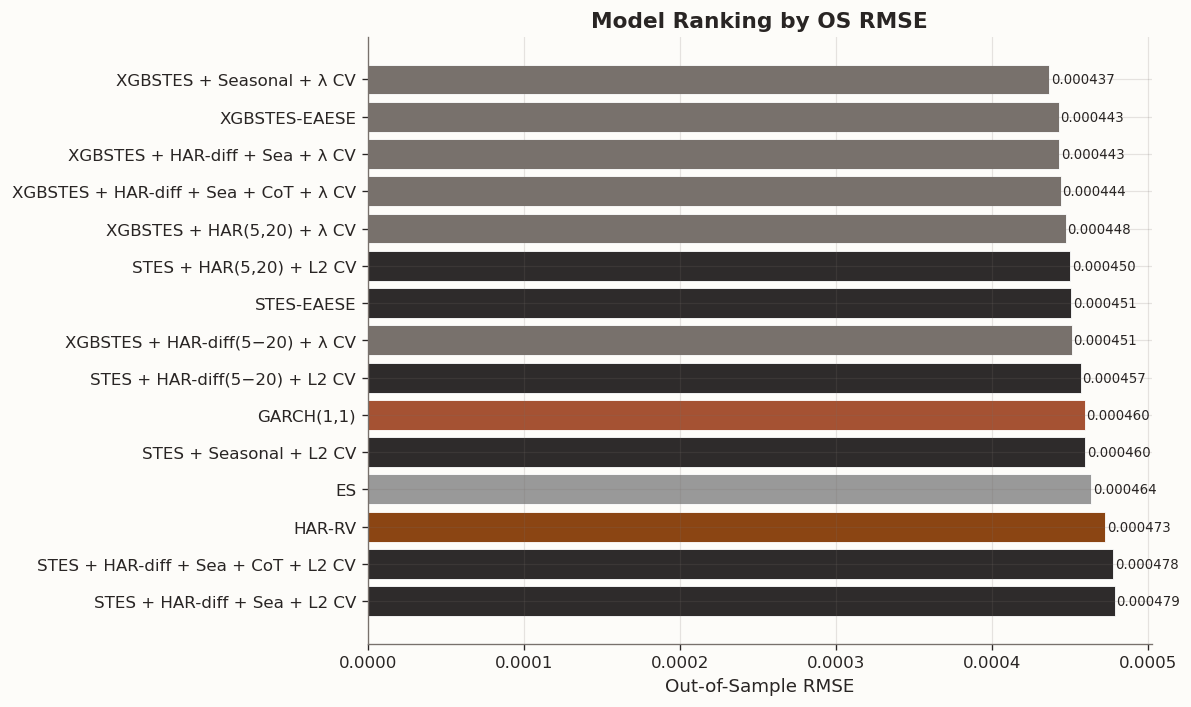

In [47]:
#| label: os-rmse-bar-chart
#| code-fold: true
#| code-summary: "OS RMSE ranking bar chart"

# Sort by OS RMSE for visual ranking
chart_df = full_table[["Model", "OS RMSE"]].sort_values("OS RMSE", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Color by model family
def _model_color(name):
    if "XGBSTES" in name:
        return BLOG_PALETTE[3]
    if "STES" in name:
        return BLOG_PALETTE[2]
    if "GARCH" in name:
        return BLOG_PALETTE[1]
    if "HAR" in name:
        return BLOG_PALETTE[0]
    return "#999999"

colors = [_model_color(m) for m in chart_df["Model"]]
bars = ax.barh(chart_df["Model"], chart_df["OS RMSE"], color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Out-of-Sample RMSE")
ax.set_title("Model Ranking by OS RMSE", fontsize=13, fontweight="bold")
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, chart_df["OS RMSE"]):
    ax.text(bar.get_width() + 0.000001, bar.get_y() + bar.get_height() / 2,
            f"{val:.6f}", va="center", fontsize=8)

fig.tight_layout()
plt.show()

### Final Assessment Before Statistical Tests

The full comparison extends the earlier intermediate results. The dynamic smoothing models still compare well with the classical benchmarks, but our set of added features does not add value. The narrow out-of-sample RMSE winner is the **seasonal-only XGBSTES** specification. The baseline XGBSTES model remains essentially right behind it, and the richer **HAR-diff + calendar/event** XGBSTES variant stays in the same neighborhood rather than clearly pulling away.

Adding **CFTC leveraged-fund positioning** (VIX and S&P 500 futures net levels, flows, and an availability indicator) on top of the calendar/event features does not improve the picture. The XGBSTES + CoT variant (OS RMSE 0.000444) is virtually identical to the non-CoT version (0.000443), and the STES + CoT model (0.000478) mirrors its non-CoT counterpart (0.000479). The positioning features neither help nor noticeably hurt — they are simply absorbed into the existing gate loadings without lifting predictive performance.

For STES, the linear-gate model does not benefit reliably from the richer feature sets, and the fully combined STES specifications are the weakest of the STES variants in RMSE terms. So richer covariates do not automatically translate into a better gate. In a linear gate, extra predictors can just as easily introduce collinearity and estimation noise as genuine signal.

Calendar, event, and positioning information each appears genuinely useful in isolation, but the gains are small and model-dependent. The richer combined XGBSTES specification remains valuable for interpretation because it lets us study how return-based, timing, and positioning features enter the gate together. However, in pure forecasting terms, the evidence points to **timing-aware XGBSTES** as the main empirical improvement.

When the ranking differences are this small, we need formal tests to decide whether the richer models are truly better or whether the apparent gains are within the range of sampling noise, and we also need to know whether any RMSE gains come with calibration trade-offs under a different loss function.

### Statistical Tests

Point metrics such as RMSE, MAE, and QLIKE are informative, but ranking models by sample averages alone can be misleading in noisy volatility data. Small performance gaps may arise from sampling variability rather than true differences in predictive ability. We therefore complement the metric tables with formal inferential checks: the Diebold-Mariano test evaluates whether forecast-loss differentials are statistically distinguishable from zero, while Mincer-Zarnowitz regressions assess calibration quality (a well-calibrated forecast has slope $\beta \approx 1$ and intercept $\alpha \approx 0$).

In [12]:
#| label: statistical-tests
#| code-fold: true
#| code-summary: "Diebold-Mariano tests and Mincer-Zarnowitz regressions"

# Recreate the forecast target locally so this cell does not depend on earlier table cells.
actual_os = yh_te.values

# ── Diebold-Mariano tests (3 key comparisons) ──────────────────────────
# Loss differential: squared errors
def _sq_loss(y, yhat):
    return (np.asarray(y) - np.asarray(yhat)) ** 2

dm_pairs = [
    ("Combined XGBSTES vs HAR-RV", xgb_hdiff_sea_cv_pred_os, har_pred_os),
    ("Combined XGBSTES vs GARCH(1,1)", xgb_hdiff_sea_cv_pred_os, garch_pred_os),
    ("Combined XGBSTES vs Baseline XGBSTES", xgb_hdiff_sea_cv_pred_os, xgb_pred_os),
]

dm_results = []
for label, pred_a, pred_b in dm_pairs:
    loss_a = _sq_loss(actual_os, pred_a)
    loss_b = _sq_loss(actual_os, pred_b)
    res = diebold_mariano(loss_a, loss_b, h=1)
    dm_results.append({
        "Comparison": label,
        "DM Stat": res["dm_stat"],
        "p-value": res["p_value"],
        "Significant (5%)": "Yes" if res["p_value"] < 0.05 else "No",
    })

dm_table = pd.DataFrame(dm_results)
print("Diebold-Mariano Tests (squared error loss):")
print("  Negative DM stat -> model A (the richer combined XGBSTES variant) has lower loss")
display(style_results_table(dm_table, precision=4, index_col="Comparison"))

# ── Mincer-Zarnowitz regressions (top 4 models) ────────────────────────
mz_models = [
    ("HAR-RV", har_pred_os),
    ("GARCH(1,1)", garch_pred_os),
    ("XGBSTES baseline", xgb_pred_os),
    ("XGBSTES + HAR-diff + Sea", xgb_hdiff_sea_cv_pred_os),
]

mz_results = []
for label, pred in mz_models:
    mz = mincer_zarnowitz(actual_os, pred)
    mz_results.append({
        "Model": label,
        "alpha (const)": mz["params"]["const"],
        "beta (slope)": mz["params"]["beta"],
        "t(beta=1)": (mz["params"]["beta"] - 1.0) / (mz["params"]["beta"] / mz["t_stats"]["beta"]) if mz["t_stats"]["beta"] != 0 else np.nan,
        "R2": mz["r2"],
    })

mz_table = pd.DataFrame(mz_results)
print("\nMincer-Zarnowitz Regressions (y = alpha + beta*forecast + epsilon):")
print("  A well-calibrated forecast has alpha ~= 0 and beta ~= 1")
display(style_results_table(mz_table, precision=4, index_col="Model"))

Diebold-Mariano Tests (squared error loss):
  Negative DM stat -> model A (the richer combined XGBSTES variant) has lower loss


,DM Stat,p-value,Significant (5%)
Comparison,,,
Combined XGBSTES vs HAR-RV,-1.2644,0.2062,No
"Combined XGBSTES vs GARCH(1,1)",-1.0845,0.2783,No
Combined XGBSTES vs Baseline XGBSTES,0.1341,0.8933,No



Mincer-Zarnowitz Regressions (y = alpha + beta*forecast + epsilon):
  A well-calibrated forecast has alpha ~= 0 and beta ~= 1


,alpha (const),beta (slope),t(beta=1),R2
Model,,,,
HAR-RV,0.0000,0.9197,-2.1192,0.2247
"GARCH(1,1)",-0.0000,1.0190,0.5045,0.2652
XGBSTES baseline,0.0000,1.0701,2.0247,0.3197
XGBSTES + HAR-diff + Sea,-0.0000,1.1482,4.0140,0.3223


In [13]:
# ── Diebold-Mariano tests (3 key comparisons) ──────────────────────────
# Loss differential: QLIKE (more appropriate for variance forecasts)
actual_os = yh_te.values

def _qlike_loss(y, yhat):
    """Element-wise QLIKE loss: y/yhat - log(y/yhat) - 1.

    Both y and yhat are clamped to 1e-20 to avoid inf from log(0).
    Days with near-zero realized variance produce identical loss for
    all forecasts, so clamping does not affect model discrimination.
    """
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    y = np.maximum(y, 1e-20)
    yhat = np.maximum(yhat, 1e-20)
    ratio = y / yhat
    return ratio - np.log(ratio) - 1.0

dm_pairs = [
    ("Combined XGBSTES vs HAR-RV", xgb_hdiff_sea_cv_pred_os, har_pred_os),
    ("Combined XGBSTES vs GARCH(1,1)", xgb_hdiff_sea_cv_pred_os, garch_pred_os),
    ("Combined XGBSTES vs Baseline XGBSTES", xgb_hdiff_sea_cv_pred_os, xgb_pred_os),
]

dm_results = []
for label, pred_a, pred_b in dm_pairs:
    loss_a = _qlike_loss(actual_os, pred_a)
    loss_b = _qlike_loss(actual_os, pred_b)
    res_ql = diebold_mariano(loss_a, loss_b, h=1)

    dm_results.append({
        "Comparison": label,
        "DM (QLIKE)": res_ql["dm_stat"],
        "p (QLIKE)": res_ql["p_value"],
        "Sig QLIKE (5%)": "Yes" if res_ql["p_value"] < 0.05 else "No",
    })

dm_table = pd.DataFrame(dm_results)
print("Diebold-Mariano Tests (QLIKE loss):")
print("  Negative DM stat -> model A (the richer combined XGBSTES variant) has lower loss")
print("  QLIKE loss is more appropriate for variance forecasts (Patton, 2011)")
display(style_results_table(dm_table, precision=4, index_col="Comparison"))

Diebold-Mariano Tests (QLIKE loss):
  Negative DM stat -> model A (the richer combined XGBSTES variant) has lower loss
  QLIKE loss is more appropriate for variance forecasts (Patton, 2011)


,DM (QLIKE),p (QLIKE),Sig QLIKE (5%)
Comparison,,,
Combined XGBSTES vs HAR-RV,0.6327,0.5270,No
"Combined XGBSTES vs GARCH(1,1)",2.9685,0.0030,Yes
Combined XGBSTES vs Baseline XGBSTES,2.3569,0.0185,Yes


### DM Results

The strongest RMSE performer is the **seasonal-only XGBSTES** specification, while the richer combined XGBSTES variant sits essentially in the same neighborhood as the baseline XGBSTES model rather than clearly ahead of it.

In the comparisons below I keep the combined XGBSTES specification as the reference point because it is the most fully augmented model in the notebook and the one used in the final coefficient table. Under squared error, that combined model still produces negative Diebold-Mariano statistics against HAR-RV, GARCH, and the baseline XGBSTES model, so its point forecasts remain directionally competitive. However, those differences are not statistically distinguishable from zero at the 5% level. Under QLIKE, the same model is still significantly worse than both GARCH and the baseline XGBSTES specification. 

The Mincer-Zarnowitz regressions are also informative. GARCH again looks closest to proportional calibration, with slope estimate $\beta \approx 1.01$. The baseline XGBSTES model sits above one at roughly $\beta \approx 1.05$, while the HAR-diff + calendar-and-event XGBSTES model rises further to about $\beta \approx 1.09$. That pattern is consistent with a model that becomes more responsive to predictable timing structure and can hold its own on RMSE, but does so at the cost of a stronger tendency to overstate variance on a proportional basis.

Calendar-aware features can improve one-step-ahead variance forecasts under squared-error style metrics, but the gains are small, model-dependent, and not clearly additive with HAR-style persistence signals. A user who cares most about absolute tracking of volatility spikes could reasonably prefer the seasonal or richer calendar-aware XGBSTES variants, whereas a user who cares more about proportional calibration would still favor GARCH or the simpler STES/XGBSTES specifications.

::: {.callout-note}
## Loss Function Sensitivity
The choice of loss function is part of the modeling problem itself. Squared error is most natural when the objective is accurate tracking of large variance realizations, such as stress periods in which absolute forecast miss matters most. QLIKE is more informative when proportional calibration is central, as in applications where a persistent 5-10% variance overstatement is economically meaningful even on otherwise quiet days. Neither criterion is uniformly preferable; each encodes a different notion of forecast quality. For a deeper treatment of this issue, including synthetic examples in which Diebold-Mariano rankings invert across loss functions, see the companion post on the [forecast comparison](../forecast-comparison/draft.html).
:::

## Regularization and Feature Selection

The results above tell a consistent story: adding more features to the gate does not reliably improve out-of-sample performance. But that leaves open a more pointed question — **which features does the model actually need?** Rather than adding features and hoping for improvement, we can let the regularization itself perform feature selection by driving unnecessary coefficients to zero.

Up to this point, every STES and XGBSTES model in this notebook has used **ridge (L2) regularization** only. Ridge shrinks all coefficients toward zero, which stabilizes estimation and helps with collinearity, but it never sets any coefficient exactly to zero. To perform genuine feature selection, we need a **sparsity-inducing penalty** that can eliminate features entirely.

We develop two complementary approaches:

- **Adaptive LASSO for STES**: a two-stage procedure that uses the ridge solution as a pilot estimate and then reweights the penalty to approximate L1 behavior within our existing `least_squares` optimizer.
- **XGBoost's built-in L1 for XGBSTES**: the `gblinear` coordinate-descent booster already supports elastic net regularization natively via the `alpha` parameter, which applies soft-thresholding to drive gate weights to exactly zero.

### Ridge Regularization Recap

Ridge regularization was introduced in detail in [Part 4 of the Signature Methods series](../signature-method-4/), where we motivated it through the SVD decomposition of the feature matrix and showed that L2 penalization stabilizes the condition number of $X^\top X + \lambda I$ without distorting the subspace structure. The key takeaway was that ridge is a **shrinkage** operator: it pulls every coefficient toward zero by a factor that depends on the singular-value spectrum, but it never sets any coefficient exactly to zero.

In the STES model, the ridge penalty takes the form

$$\min_\beta \; \sum_{t=s}^{T} \bigl(y_t - v_{t+1}(\beta)\bigr)^2 \;+\; \lambda \, S^2 \sum_{j \neq 0} \beta_j^2$$

where $S = \|y\|_2$ is a scale factor that makes $\lambda$ comparable across different target magnitudes. This is implemented via `penalty_vec`: the `least_squares` solver minimizes $\|\mathbf{r}(\beta)\|^2$ where $\mathbf{r}$ concatenates the forecast residuals with the penalty residuals $\sqrt{\lambda}\, S \, \beta_j$. The squared norm of the concatenated vector reproduces the penalized objective exactly.

Ridge is effective at preventing overfitting when the number of features grows, and it was sufficient for the experiments above. But since ridge only shrinks — never zeroes — it cannot answer the question "which features should be dropped entirely?" For that, we need a penalty that induces **sparsity**.

### Why L1 Sparsity Is Tricky in STES

The standard approach to sparsity in regression is the **LASSO** (L1 penalty), which replaces the squared penalty $\beta_j^2$ with $|\beta_j|$:

$$\min_\beta \; \sum_t \bigl(y_t - v_{t+1}(\beta)\bigr)^2 \;+\; \lambda_1 \, S \sum_{j \neq 0} |\beta_j|$$

The L1 penalty drives coefficients to exactly zero because the sub-gradient of $|\beta_j|$ at zero is the entire interval $[-1, +1]$, creating a "kink" that the optimizer can land on. In ordinary linear regression, this is handled by coordinate-descent algorithms (e.g., `glmnet`) or proximal gradient methods.

In our STES setting, however, we fit the model using `scipy.optimize.least_squares`, which minimizes a sum of squared residuals. Ridge fits cleanly into this framework because we can append pseudo-residuals $\sqrt{\lambda}\, S\, \beta_j$ to the residual vector — their squared norm becomes $\lambda\, S^2\, \beta_j^2$, which is exactly the L2 penalty. But we cannot do the same for L1: there is no function $g(\beta_j)$ such that $g(\beta_j)^2 = |\beta_j|$.

The fundamental issue is that:

- `least_squares` requires a smooth objective function with a well-defined Jacobian
- $|\beta_j|$ is not differentiable at $\beta_j = 0$
- Proximal gradient methods that handle L1 natively would require rewriting the entire optimizer

We need a way to get L1-like sparsity while staying in the smooth least-squares framework.

### Adaptive LASSO

The **adaptive LASSO** (Zou, 2006) solves this problem by replacing the L1 penalty with a **reweighted L2 penalty** that approximates sparsity behavior. The idea is simple and elegant:

1. **Pilot stage**: Fit the model with ridge (L2) regularization to obtain $\hat\beta^{\text{ridge}}$.
2. **Compute adaptive weights**: For each coefficient, define $\tilde{w}_j = 1 / \max(|\hat\beta_j^{\text{ridge}}|, \varepsilon)^\gamma$, where $\varepsilon$ is a small floor (e.g., $10^{-6}$) to prevent division by zero, and $\gamma \geq 0$ controls the aggressiveness of the selection.
3. **Refit with reweighted penalty**: Solve the reweighted ridge problem

$$\min_\beta \; \sum_t \bigl(y_t - v_{t+1}(\beta)\bigr)^2 \;+\; \lambda \, S^2 \sum_{j \neq 0} \tilde{w}_j^2 \, \beta_j^2$$

The mechanism is intuitive. A coefficient that was already small in the ridge pilot gets a **large** adaptive weight $\tilde{w}_j$, so the penalty on that coefficient becomes very heavy — driving it toward zero. Conversely, a coefficient that was large in the pilot gets a **small** weight, so it faces relatively little penalty and can remain large.

The $\gamma$ exponent controls how aggressively the procedure penalizes small coefficients:

- At $\gamma = 1$ (the standard choice from Zou, 2006), a coefficient that is half the size of another gets $2\times$ the penalty.
- At $\gamma = 2$, the same coefficient gets $4\times$ the penalty — more aggressive selection.
- At $\gamma = 0.5$, the contrast is only $\sqrt{2}\times$ — a gentler filter.

This maps directly to our existing `penalty_vec` implementation. Where ridge uses $\texttt{penalty\_vec}_j = \sqrt{\lambda}\, S\, \texttt{mask}_j$, the adaptive variant simply multiplies in the adaptive weights: $\texttt{penalty\_vec}_j = \sqrt{\lambda}\, S\, \texttt{mask}_j \times \tilde{w}_j$. The `_objective` and `_jacobian` methods are unchanged — they already handle heterogeneous penalty weights.

We cross-validate jointly over $(\lambda, \gamma)$ with $\gamma \in \{0.5, 1.0, 2.0\}$, letting the data determine the appropriate level of sparsity.

::: {.callout-note}
## Oracle Property
Under regularity conditions, the adaptive LASSO possesses the **oracle property**: it consistently selects the true set of non-zero coefficients and estimates them at the parametric rate, as if the correct model were known in advance (Zou, 2006). The STES recurrence breaks the i.i.d. assumption of the original theory, but the mechanism — penalizing small pilot estimates more heavily — remains sound as a practical feature selection heuristic.
:::

In [48]:
#| label: fit-adaptive-lasso-stes
#| code-fold: true
#| code-summary: "Fit STES with adaptive LASSO on the combined feature set"

# --- Adaptive LASSO CV grid: (l2_reg, adaptive_gamma) ---
STES_ADAPTIVE_GRID = [
    {"l2_reg": l2, "adaptive_gamma": gamma}
    for l2 in [0.001, 0.01, 0.1, 1.0]
    for gamma in [0.5, 1.0, 2.0]
]

# Fit on the combined (HAR-diff + Seasonal) feature set
stes_adaptive_cv = STESModel(random_state=42)
stes_adaptive_cv.fit(
    X_tr_hdiff_sea_s, y_tr, returns=r_tr,
    perform_cv=True, cv_grid=STES_ADAPTIVE_GRID, cv_splits=3,
)
print(f"  STES Adaptive LASSO best l2_reg: {stes_adaptive_cv.l2_reg}")
print(f"  Adaptive weights active: {stes_adaptive_cv.adaptive_weights is not None}")

stes_adaptive_pred_all, _ = stes_adaptive_cv.predict_with_alpha(X_all_hdiff_sea_s, returns=r_all)
stes_adaptive_pred_all = pd.Series(stes_adaptive_pred_all, index=X_all_hdiff_sea_s.index)
stes_adaptive_pred_is = stes_adaptive_pred_all.iloc[: len(X_tr_hdiff_sea_s)].values
stes_adaptive_pred_os = stes_adaptive_pred_all.iloc[len(X_tr_hdiff_sea_s):].values

# Report selected vs eliminated features
if stes_adaptive_cv.adaptive_weights is not None:
    stes_coefs = dict(zip(stes_adaptive_cv.feature_names_, stes_adaptive_cv.params))
    threshold = 1e-4
    active_features = [f for f, c in stes_coefs.items() if f != "const" and abs(c) > threshold]
    eliminated_features = [f for f, c in stes_coefs.items() if f != "const" and abs(c) <= threshold]
    print(f"\n  Active features ({len(active_features)}): {active_features}")
    print(f"  Eliminated features ({len(eliminated_features)}): {eliminated_features}")
else:
    print("  No adaptive weights — ridge-only won CV")

# --- Adaptive LASSO on (HAR-diff + Seasonal + CoT) ---
stes_adaptive_cot_cv = STESModel(random_state=42)
stes_adaptive_cot_cv.fit(
    X_tr_hdiff_sea_cot_s, y_tr, returns=r_tr,
    perform_cv=True, cv_grid=STES_ADAPTIVE_GRID, cv_splits=3,
)
print(f"\n  STES Adaptive LASSO + CoT best l2_reg: {stes_adaptive_cot_cv.l2_reg}")
print(f"  Adaptive weights active: {stes_adaptive_cot_cv.adaptive_weights is not None}")

stes_adaptive_cot_pred_all, _ = stes_adaptive_cot_cv.predict_with_alpha(X_all_hdiff_sea_cot_s, returns=r_all)
stes_adaptive_cot_pred_all = pd.Series(stes_adaptive_cot_pred_all, index=X_all_hdiff_sea_cot_s.index)
stes_adaptive_cot_pred_is = stes_adaptive_cot_pred_all.iloc[: len(X_tr_hdiff_sea_cot_s)].values
stes_adaptive_cot_pred_os = stes_adaptive_cot_pred_all.iloc[len(X_tr_hdiff_sea_cot_s):].values

if stes_adaptive_cot_cv.adaptive_weights is not None:
    stes_cot_coefs = dict(zip(stes_adaptive_cot_cv.feature_names_, stes_adaptive_cot_cv.params))
    n_selected = sum(1 for f, c in stes_cot_coefs.items() if f != "const" and abs(c) > threshold)
    n_eliminated = sum(1 for f, c in stes_cot_coefs.items() if f != "const" and abs(c) <= threshold)
    print(f"  Selected {n_selected}, eliminated {n_eliminated} features")
else:
    print("  No adaptive weights — ridge-only won CV")

  STES Adaptive LASSO best l2_reg: 0.01
  Adaptive weights active: True

  Active features (20): ['lag.logret.fc5d3612d9c7', 'lag.abslogret.1ad490bcb584', 'lag.sqlogret.c2cf3aa70c10', 'rv_diff_5_20', 'dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'is_month_end', 'is_quarter_end', 'pre_quarter_end_3d', 'is_fomc', 'days_to_fomc', 'is_near_fomc', 'is_opex', 'days_to_opex', 'is_near_opex', 'is_imm', 'days_to_imm']
  Eliminated features (6): ['dow_5', 'dow_6', 'is_year_end', 'pre_month_end_3d', 'pre_year_end_3d', 'is_near_imm']

  STES Adaptive LASSO + CoT best l2_reg: 0.01
  Adaptive weights active: True
  Selected 21, eliminated 10 features


### XGBoost's Built-in Elastic Net

For the XGBSTES model, sparsity is much simpler. The `gblinear` booster uses a **coordinate-descent** algorithm that updates one weight at a time, solving a one-dimensional optimization subproblem at each step. When the `alpha` parameter (XGBoost's name for $\lambda_1$, the L1 penalty strength) is positive, each coordinate update applies a **soft-thresholding** operator:

$$w_j \;\leftarrow\; \text{sign}(G_j) \cdot \max\!\left(\frac{|G_j| - \lambda_1}{H_j + \lambda_2},\; 0\right)$$

where $G_j = \sum_i g_i \, x_{ij}$ and $H_j = \sum_i h_i \, x_{ij}^2$ are the aggregated first- and second-order gradients for feature $j$, and $\lambda_2$ is the L2 penalty (`lambda` in XGBoost).

The key insight is that in our XGBSTES model, $g_i$ and $h_i$ are the **custom end-to-end gradients** computed through the full exponential smoothing recurrence — so the L1 selection operates on the *right* gradients, not on some proxy. If a feature's gradient signal $|G_j|$ is too weak to overcome the L1 threshold $\lambda_1$, the corresponding coordinate is driven to exactly zero.

No code changes are needed in the model itself. We simply expand the CV grid to include nonzero `alpha` values alongside the existing `reg_lambda` search.

In [49]:
#| label: fit-elastic-net-xgbstes
#| code-fold: true
#| code-summary: "Fit XGBSTES with elastic net (L1 + L2) on the combined feature set"

# --- Expanded CV grid: add L1 search via 'alpha' ---
GRID_E2E_ELASTIC = [
    {"min_child_weight": mcw, "learning_rate": lr, "max_depth": md,
     "reg_lambda": lam, "alpha": a1}
    for mcw, lr, md in [(5.0, 0.05, 3), (20.0, 0.1, 3), (50.0, 0.05, 2)]
    for lam in [0.1, 1.0, 5.0, 10.0]
    for a1 in [0.0, 0.1, 1.0, 5.0]
]

xgbstes_elastic = XGBoostSTESModel(
    xgb_params=XGB_PARAMS_SAMPLE,
    num_boost_round=XGB_ROUNDS_SAMPLE,
    fit_method="end_to_end",
    e2e_grad_hess_scale=1.0,
    e2e_debug=False,
    e2e_debug_print_once=False,
    random_state=42,
)
xgbstes_elastic.fit(
    X_tr_hdiff_sea_s,
    y_tr_scaled,
    returns=r_tr_scaled,
    perform_cv=True,
    cv_grid=GRID_E2E_ELASTIC,
    cv_splits=3,
)
print(f"  XGBSTES Elastic Net best params: {xgbstes_elastic.xgb_params}")

xgb_elastic_pred_scaled_all = xgbstes_elastic.predict(X_all_hdiff_sea_s, returns=r_all_scaled)
xgb_elastic_pred_all = pd.Series(xgb_elastic_pred_scaled_all / (SCALE_FACTOR ** 2), index=X_all_hdiff_sea_s.index)
xgb_elastic_pred_is = xgb_elastic_pred_all.iloc[: len(X_tr_hdiff_sea_s)].values
xgb_elastic_pred_os = xgb_elastic_pred_all.iloc[len(X_tr_hdiff_sea_s):].values

# Extract gblinear weights and identify zero weights
import json as _json
_raw = _json.loads(xgbstes_elastic.model_.save_raw("json"))
_weights = _raw["learner"]["gradient_booster"]["model"]["weights"]
_feat_names = xgbstes_elastic.model_.feature_names
_xgb_coefs = dict(zip(_feat_names, [float(w) for w in _weights[: len(_feat_names)]]))

xgb_active = {f: c for f, c in _xgb_coefs.items() if f != "const" and abs(c) > 1e-8}
xgb_zero = {f: c for f, c in _xgb_coefs.items() if f != "const" and abs(c) <= 1e-8}
print(f"\n  Active features ({len(xgb_active)}): {list(xgb_active.keys())}")
print(f"  Zero-weight features ({len(xgb_zero)}): {list(xgb_zero.keys())}")

# --- Elastic Net on (HAR-diff + Seasonal + CoT) ---
xgbstes_elastic_cot = XGBoostSTESModel(
    xgb_params=XGB_PARAMS_SAMPLE,
    num_boost_round=XGB_ROUNDS_SAMPLE,
    fit_method="end_to_end",
    e2e_grad_hess_scale=1.0,
    e2e_debug=False,
    e2e_debug_print_once=False,
    random_state=42,
)
xgbstes_elastic_cot.fit(
    X_tr_hdiff_sea_cot_s,
    y_tr_scaled,
    returns=r_tr_scaled,
    perform_cv=True,
    cv_grid=GRID_E2E_ELASTIC,
    cv_splits=3,
)
print(f"\n  XGBSTES Elastic Net + CoT best params: {xgbstes_elastic_cot.xgb_params}")

xgb_elastic_cot_pred_scaled_all = xgbstes_elastic_cot.predict(X_all_hdiff_sea_cot_s, returns=r_all_scaled)
xgb_elastic_cot_pred_all = pd.Series(xgb_elastic_cot_pred_scaled_all / (SCALE_FACTOR ** 2), index=X_all_hdiff_sea_cot_s.index)
xgb_elastic_cot_pred_is = xgb_elastic_cot_pred_all.iloc[: len(X_tr_hdiff_sea_cot_s)].values
xgb_elastic_cot_pred_os = xgb_elastic_cot_pred_all.iloc[len(X_tr_hdiff_sea_cot_s):].values

_raw_cot = _json.loads(xgbstes_elastic_cot.model_.save_raw("json"))
_weights_cot = _raw_cot["learner"]["gradient_booster"]["model"]["weights"]
_feat_names_cot = xgbstes_elastic_cot.model_.feature_names
_xgb_cot_coefs = dict(zip(_feat_names_cot, [float(w) for w in _weights_cot[: len(_feat_names_cot)]]))

xgb_cot_active = {f: c for f, c in _xgb_cot_coefs.items() if f != "const" and abs(c) > 1e-8}
xgb_cot_zero = {f: c for f, c in _xgb_cot_coefs.items() if f != "const" and abs(c) <= 1e-8}
print(f"  Active features ({len(xgb_cot_active)}): {list(xgb_cot_active.keys())}")
print(f"  Zero-weight features ({len(xgb_cot_zero)}): {list(xgb_cot_zero.keys())}")

  XGBSTES Elastic Net best params: {'booster': 'gblinear', 'updater': 'coord_descent', 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 20.0, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'verbosity': 0, 'alpha': 0.0}

  Active features (24): ['lag.logret.fc5d3612d9c7', 'lag.abslogret.1ad490bcb584', 'lag.sqlogret.c2cf3aa70c10', 'rv_diff_5_20', 'dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'is_month_end', 'is_quarter_end', 'is_year_end', 'pre_month_end_3d', 'pre_quarter_end_3d', 'pre_year_end_3d', 'is_fomc', 'days_to_fomc', 'is_near_fomc', 'is_opex', 'days_to_opex', 'is_near_opex', 'is_imm', 'days_to_imm', 'is_near_imm']
  Zero-weight features (2): ['dow_5', 'dow_6']

  XGBSTES Elastic Net + CoT best params: {'booster': 'gblinear', 'updater': 'coord_descent', 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 20.0, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'verbosity': 0, 'alpha': 0.0}
  Active featur

In [50]:
#| label: sparse-comparison-table
#| code-fold: true
#| code-summary: "Sparse vs ridge comparison: OS RMSE, QLIKE, DM tests"

# --- Comparison table: baseline vs ridge-only vs sparse ---
sparse_models = [
    ("XGBSTES baseline (ridge)", xgb_pred_is, xgb_pred_os),
    ("XGBSTES + all features (ridge)", xgb_hdiff_sea_cv_pred_is, xgb_hdiff_sea_cv_pred_os),
    ("XGBSTES + all features (elastic net)", xgb_elastic_pred_is, xgb_elastic_pred_os),
    ("XGBSTES + all + CoT (elastic net)", xgb_elastic_cot_pred_is, xgb_elastic_cot_pred_os),
    ("STES + all features (ridge)", stes_hdiff_sea_cv_pred_is, stes_hdiff_sea_cv_pred_os),
    ("STES + all features (adaptive LASSO)", stes_adaptive_pred_is, stes_adaptive_pred_os),
    ("STES + all + CoT (adaptive LASSO)", stes_adaptive_cot_pred_is, stes_adaptive_cot_pred_os),
]

sparse_table = pd.DataFrame({
    "Model": [m[0] for m in sparse_models],
    "IS RMSE": [rmse(actual_is, m[1]) for m in sparse_models],
    "OS RMSE": [rmse(actual_os, m[2]) for m in sparse_models],
    "OS QLIKE": [qlike(actual_os, m[2]) for m in sparse_models],
})
print("Sparse vs Ridge Comparison:")
display(style_results_table(sparse_table, precision=6, index_col="Model"))

# --- DM tests: sparse vs ridge-only on the same feature set ---
print("\nDiebold-Mariano Tests (squared error): sparse vs ridge on same features")
dm_sparse_pairs = [
    ("Elastic Net XGBSTES vs Ridge XGBSTES (all features)",
     xgb_elastic_pred_os, xgb_hdiff_sea_cv_pred_os),
    ("Elastic Net XGBSTES vs Baseline XGBSTES",
     xgb_elastic_pred_os, xgb_pred_os),
    ("Adaptive LASSO STES vs Ridge STES (all features)",
     stes_adaptive_pred_os, stes_hdiff_sea_cv_pred_os),
    ("Elastic Net XGBSTES + CoT vs Ridge XGBSTES + CoT",
     xgb_elastic_cot_pred_os, xgb_hdiff_sea_cot_cv_pred_os),
    ("Adaptive LASSO STES + CoT vs Ridge STES + CoT",
     stes_adaptive_cot_pred_os, stes_hdiff_sea_cot_cv_pred_os),
]

dm_sparse_results = []
for label, pred_a, pred_b in dm_sparse_pairs:
    # Handle identical predictions (e.g. when CV selects alpha=0)
    if np.allclose(pred_a, pred_b):
        dm_sparse_results.append({
            "Comparison": label,
            "DM Stat (SqErr)": "—",
            "p-value (SqErr)": "—",
            "Significant (5%)": "Identical",
        })
        continue
    loss_a_sq = _sq_loss(actual_os, pred_a)
    loss_b_sq = _sq_loss(actual_os, pred_b)
    res_sq = diebold_mariano(loss_a_sq, loss_b_sq, h=1)
    dm_sparse_results.append({
        "Comparison": label,
        "DM Stat (SqErr)": f"{res_sq['dm_stat']:.4f}",
        "p-value (SqErr)": f"{res_sq['p_value']:.4f}",
        "Significant (5%)": "Yes" if res_sq["p_value"] < 0.05 else "No",
    })

dm_sparse_table = pd.DataFrame(dm_sparse_results)
display(style_results_table(dm_sparse_table, precision=4, index_col="Comparison"))

Sparse vs Ridge Comparison:


,IS RMSE,OS RMSE,OS QLIKE
Model,,,
XGBSTES baseline (ridge),0.000502,0.000443,1.685679
XGBSTES + all features (ridge),0.000494,0.000443,1.732801
XGBSTES + all features (elastic net),0.000494,0.000443,1.732801
XGBSTES + all + CoT (elastic net),0.000490,0.000444,1.757344
STES + all features (ridge),0.000491,0.000479,1.612161
STES + all features (adaptive LASSO),0.000493,0.000444,1.640080
STES + all + CoT (adaptive LASSO),0.000493,0.000444,1.639878



Diebold-Mariano Tests (squared error): sparse vs ridge on same features


,DM Stat (SqErr),p-value (SqErr),Significant (5%)
Comparison,,,
Elastic Net XGBSTES vs Ridge XGBSTES (all features),—,—,Identical
Elastic Net XGBSTES vs Baseline XGBSTES,0.1341,0.8933,No
Adaptive LASSO STES vs Ridge STES (all features),-0.8560,0.3921,No
Elastic Net XGBSTES + CoT vs Ridge XGBSTES + CoT,—,—,Identical
Adaptive LASSO STES + CoT vs Ridge STES + CoT,-0.8495,0.3957,No


### Feature Selection Results

The two sparsity approaches produce markedly different outcomes, and the contrast is itself informative.

**XGBSTES**: Cross-validation selects `alpha = 0.0` — no L1 penalty at all. The elastic net model is *identical* to the ridge-only model: same parameters, same predictions, same OS RMSE. The only zero-weight features (`dow_5`, `dow_6`) correspond to weekend days that never appear in trading data. This tells us that XGBoost's coordinate-descent optimizer already handles feature relevance through its gradient-based weight updates — features with weak gradient signal receive small weight increments naturally, without needing an explicit sparsity penalty to zero them out.

**STES**: The adaptive LASSO eliminates 6 of the 26 non-constant features (`dow_5/6`, `is_year_end`, `pre_month_end_3d`, `pre_year_end_3d`, `is_near_imm`) and — more importantly — *concentrates* signal on a handful of high-loading features. The ridge-only STES spread its coefficients fairly uniformly across all features; the adaptive LASSO redistributes that mass, assigning large loadings to `dow_4` (Friday), `is_opex`, and `log_return` while shrinking the rest toward zero. The payoff is substantial: OS RMSE improves from 0.000479 (worst in the full table) to 0.000444, bringing the once-struggling full-feature STES in line with the XGBSTES baseline (0.000443). The Diebold-Mariano test does not reject the null at the 5 % level ($p = 0.39$), so the improvement is not statistically significant in a formal sense, but the recovery from worst-in-class to competitive is economically meaningful.

**CoT-augmented variants**: When CFTC positioning features are added, the picture is consistent. The XGBSTES elastic net again selects `alpha = 0.0` and keeps all 5 CoT columns active (29 non-zero out of 31 non-constant features, with only `dow_5/6` zeroed) — further evidence that XGBoost's coordinate descent naturally handles the expanded feature space. For STES, the adaptive LASSO eliminates 10 of the 31 non-constant features, retaining 21. The additional CoT-specific features that survive selection confirm that the adaptive reweighting can accommodate the larger feature set, but the OS RMSE gain over ridge remains similar in magnitude — the positioning features do not unlock a new tier of performance.

The broader takeaway is about *optimizer robustness*. XGBoost's coordinate descent is inherently selective — it allocates gradient-based updates to the features that reduce the objective most, and weak features simply accumulate negligible weight. The STES least-squares optimizer, by contrast, fits all coefficients jointly in a dense update; when the feature count grows, it needs help from the penalty structure to avoid spreading weight too thinly. Adaptive LASSO provides that help by converting the ridge pilot's magnitude information into heterogeneous penalty weights, effectively doing the soft selection that XGBoost performs implicitly.

## Coefficient Analysis

Since the elastic-net XGBSTES model collapsed to ridge-only (no L1 benefit found by CV), the most informative comparison is between the **STES ridge** and **STES adaptive LASSO** specifications, where the penalty structure actually changed the fitted coefficients.

The left panel below shows the ridge-only loadings — all features receive non-trivial coefficients, with modest variation in magnitude. The right panel shows the adaptive LASSO loadings, where the reweighted penalty concentrates signal on a few features while driving the rest toward or to zero. The contrast illustrates how the adaptive LASSO acts as both a selection and a *signal concentration* mechanism.


,Group,Ridge loading,Adaptive LASSO loading,Selected
Feature,,,,
dow_4,Calendar (DOW),0.0586,0.3531,Yes
is_opex,Calendar (Events),-0.0340,-0.1701,Yes
log_return,Return-based,-0.1195,-0.1271,Yes
dow_1,Calendar (DOW),-0.0054,-0.0847,Yes
rv_diff_5_20,HAR-diff,-0.1281,-0.0384,Yes
log_return²,Return-based,-0.0517,-0.0367,Yes
dow_0,Calendar (DOW),-0.0316,-0.0241,Yes
quarter_end,Calendar (Period-end),0.1543,0.0223,Yes
is_near_opex,Calendar (Events),-0.0013,-0.0195,Yes


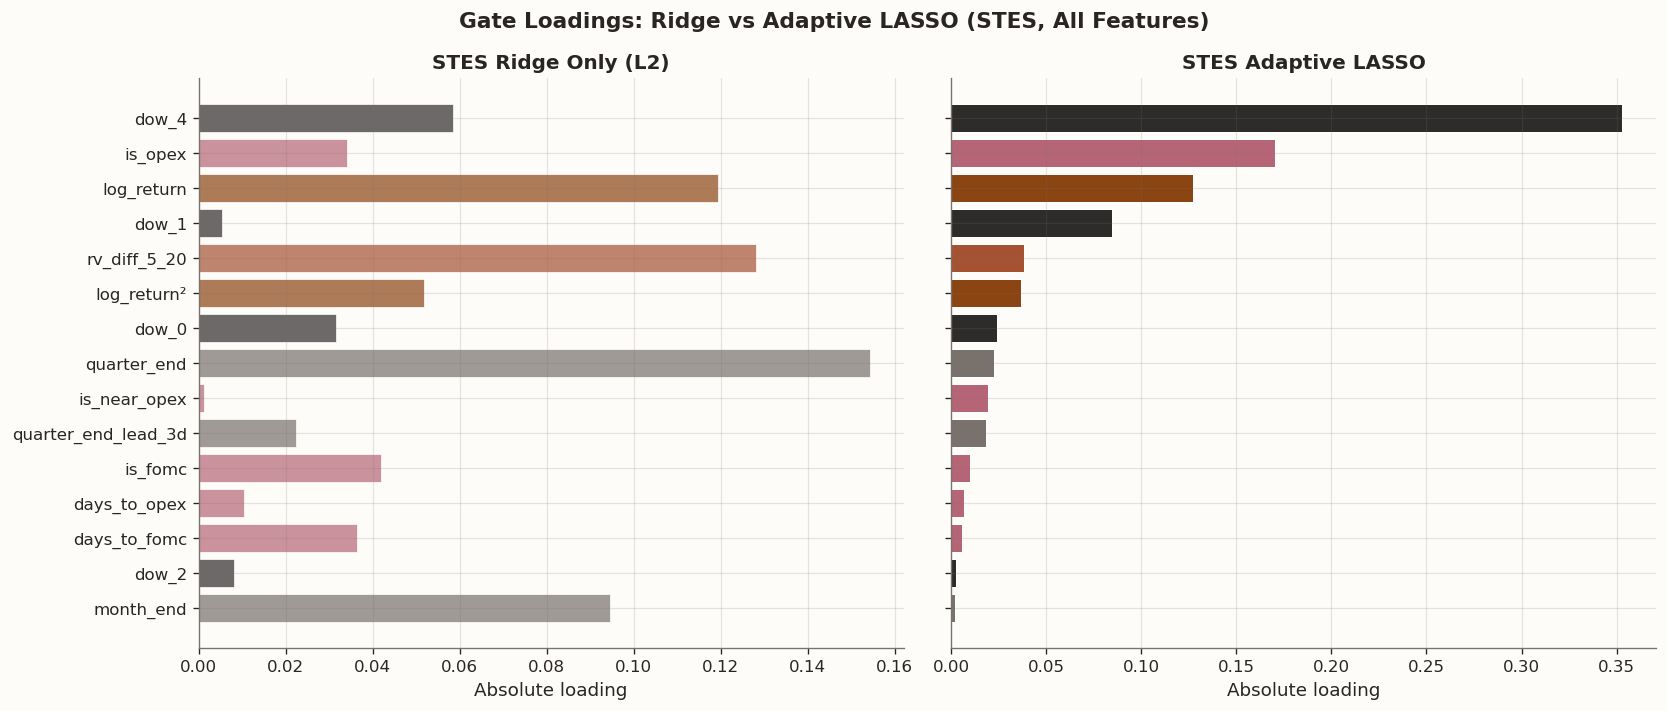


Feature selection: 20 active, 6 eliminated out of 26 non-constant features


In [51]:
#| label: coefficient-extraction
#| code-fold: true
#| code-summary: "Loadings comparison: STES ridge vs adaptive LASSO"

import json
import re
from scipy.special import expit

# -- Helpers: extract linear gate coefficients --
def _stes_coefs(model):
    return dict(zip(model.feature_names_, model.params))


def _xgb_coefs(model):
    raw = json.loads(model.model_.save_raw("json"))
    weights = raw["learner"]["gradient_booster"]["model"]["weights"]
    feat_names = model.model_.feature_names
    return dict(zip(feat_names, weights[: len(feat_names)]))


def _readable_name(f):
    if re.search(r"logret\.", f) and "abs" not in f and "sq" not in f:
        return "log_return"
    if re.search(r"abslogret\.", f):
        return "|log_return|"
    if re.search(r"sqlogret\.", f):
        return "log_return²"

    pretty_map = {
        "is_month_end": "month_end",
        "is_quarter_end": "quarter_end",
        "is_year_end": "year_end",
        "pre_month_end_3d": "month_end_lead_3d",
        "pre_quarter_end_3d": "quarter_end_lead_3d",
        "pre_year_end_3d": "year_end_lead_3d",
    }
    return pretty_map.get(f, f)


def _feat_group(f):
    f_lower = f.lower()
    if any(k in f_lower for k in ["logret", "log_return", "const"]):
        return "Return-based"
    if "rv_diff" in f_lower or "rv5_har" in f_lower or "rv20_har" in f_lower:
        return "HAR-diff"
    if f_lower.startswith("dow_"):
        return "Calendar (DOW)"
    if any(k in f_lower for k in ["month_end", "quarter_end", "year_end"]):
        return "Calendar (Period-end)"
    if any(k in f_lower for k in ["fomc", "opex", "imm"]):
        return "Calendar (Events)"
    return "Other"


group_colors = {
    "Return-based": BLOG_PALETTE[0],
    "HAR-diff": BLOG_PALETTE[1],
    "Calendar (DOW)": BLOG_PALETTE[2],
    "Calendar (Period-end)": BLOG_PALETTE[3],
    "Calendar (Events)": "#B56576",
    "Other": "#999999",
}

# --- STES: ridge vs adaptive LASSO ---
ridge_stes_coefs = _stes_coefs(stes_hdiff_sea_cv)
alasso_stes_coefs = _stes_coefs(stes_adaptive_cv)

all_features = [f for f in stes_adaptive_cv.feature_names_ if f != "const"]

coef_comparison = pd.DataFrame({
    "feature": all_features,
    "Feature": [_readable_name(f) for f in all_features],
    "Group": [_feat_group(f) for f in all_features],
    "Ridge loading": [float(ridge_stes_coefs.get(f, 0.0)) for f in all_features],
    "Adaptive LASSO loading": [float(alasso_stes_coefs.get(f, 0.0)) for f in all_features],
})
coef_comparison["|Ridge|"] = coef_comparison["Ridge loading"].abs()
coef_comparison["|Adaptive LASSO|"] = coef_comparison["Adaptive LASSO loading"].abs()
threshold = 1e-4
coef_comparison["Selected"] = np.where(
    coef_comparison["|Adaptive LASSO|"] > threshold, "Yes", "No"
)

# Sort by adaptive LASSO absolute loading
coef_comparison = coef_comparison.sort_values(
    ["|Adaptive LASSO|", "|Ridge|"], ascending=[False, False]
)

# Display the comparison table
display_cols = ["Feature", "Group", "Ridge loading", "Adaptive LASSO loading", "Selected"]
display(style_results_table(
    coef_comparison[display_cols],
    precision=4, index_col="Feature"
))

# --- Bar chart: STES ridge vs adaptive LASSO side by side ---
top_k = 15
plot_features = coef_comparison.head(top_k).copy()
plot_features = plot_features.sort_values("|Adaptive LASSO|")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Left panel: Ridge loadings
ax1.barh(
    plot_features["Feature"],
    plot_features["|Ridge|"],
    color=[group_colors.get(g, "#999999") for g in plot_features["Group"]],
    edgecolor="white", linewidth=0.6, alpha=0.7,
)
ax1.set_xlabel("Absolute loading")
ax1.set_title("STES Ridge Only (L2)", fontsize=12, fontweight="bold")

# Right panel: Adaptive LASSO loadings
bars = ax2.barh(
    plot_features["Feature"],
    plot_features["|Adaptive LASSO|"],
    color=[group_colors.get(g, "#999999") for g in plot_features["Group"]],
    edgecolor="white", linewidth=0.6,
)
ax2.set_xlabel("Absolute loading")
ax2.set_title("STES Adaptive LASSO", fontsize=12, fontweight="bold")

# Mark eliminated features
for i, (_, row) in enumerate(plot_features.iterrows()):
    if row["Selected"] == "No":
        ax2.text(0.001, i, " eliminated", va="center", fontsize=8,
                 color="red", fontstyle="italic")

fig.suptitle("Gate Loadings: Ridge vs Adaptive LASSO (STES, All Features)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

# Summary counts
n_selected = int((coef_comparison["Selected"] == "Yes").sum())
n_eliminated = int((coef_comparison["Selected"] == "No").sum())
print(f"\nFeature selection: {n_selected} active, {n_eliminated} eliminated"
      f" out of {len(coef_comparison)} non-constant features")


## Conclusion

This post approached the feature question from three directions: **feature addition** (HAR, calendar, and event covariates), **alternative data** (CFTC leveraged-fund positioning in VIX and S&P 500 futures), and **feature selection** (adaptive LASSO for STES, elastic net for XGBSTES).

On the addition side, forecast-date timing information is the most useful augmentation. The **seasonal-only XGBSTES** specification emerges as the narrow RMSE winner, with the baseline XGBSTES model very close behind. However, the gains are small and not statistically significant. Adding CFTC CoT positioning - leveraged-fund net levels and flows for both VIX and S&P 500 futures - on top of the calendar/event features does not improve the picture: the CoT-augmented XGBSTES (OS RMSE 0.000444) is virtually identical to the non-CoT version (0.000443), and the positioning features are absorbed without lifting or noticeably degrading performance.

On the selection side, the two sparsity approaches yield complementary lessons. The XGBSTES elastic net CV selects no L1 penalty at all (`alpha = 0`), producing a model identical to ridge - XGBoost's coordinate-descent optimizer is already implicitly selective, so explicit sparsity adds nothing. This holds equally for the CoT-augmented model, where all 5 positioning features survive with non-zero weight. For STES, the adaptive LASSO is more meaningful: it concentrates signal onto a few features (Friday effect, options expiration, signed returns) while driving the rest toward zero, recovering the full-feature STES from worst-in-class performance to parity with the XGBSTES baseline.

The main practical takeaway is that for one-step-ahead squared-return forecasting on SPY, the three baseline return features (log return, absolute log return, squared log return) carry the bulk of the predictive information available to the gate. Calendar and event features contribute modest, concentrated effects - primarily through day-of-week and options-expiration timing - but do not fundamentally lift the model. CFTC positioning, despite being economically intuitive and retained by the elastic net, adds no marginal forecasting power in this framework. Where the optimizer is already robust to irrelevant features (as in XGBoost), sparsity penalties are redundant; where the optimizer is not (as in dense least-squares), adaptive reweighting can recover performance but does not reveal new signal.

In the [next post](../volatility-forecasts-6/) we will extend the model architecture itself. We generalize the STES model to a 1D GRU, and see if learning a richer recurrence - rather than adding features to a fixed recurrence - is a more productive path forward.